# **Colombia**

República de Colombia, es un país soberano situado en la región noroccidental de América del Sur.

El país es travesado por la cordillera de los Andes y la llanura amazónica, es el único país de América del Sur con costas sobre los océanos Atlántico y Pacífico. Por estar muy cerca del Ecuador en una baja latitud, todos los climas que se presentan en Colombia son isotérmicos, es decir, sin amplitud térmica relevante a lo largo del año.

Por la dinámica del territorio el clima está relacionado con las estaciones según la precipitación (estación seca y estación lluviosa).

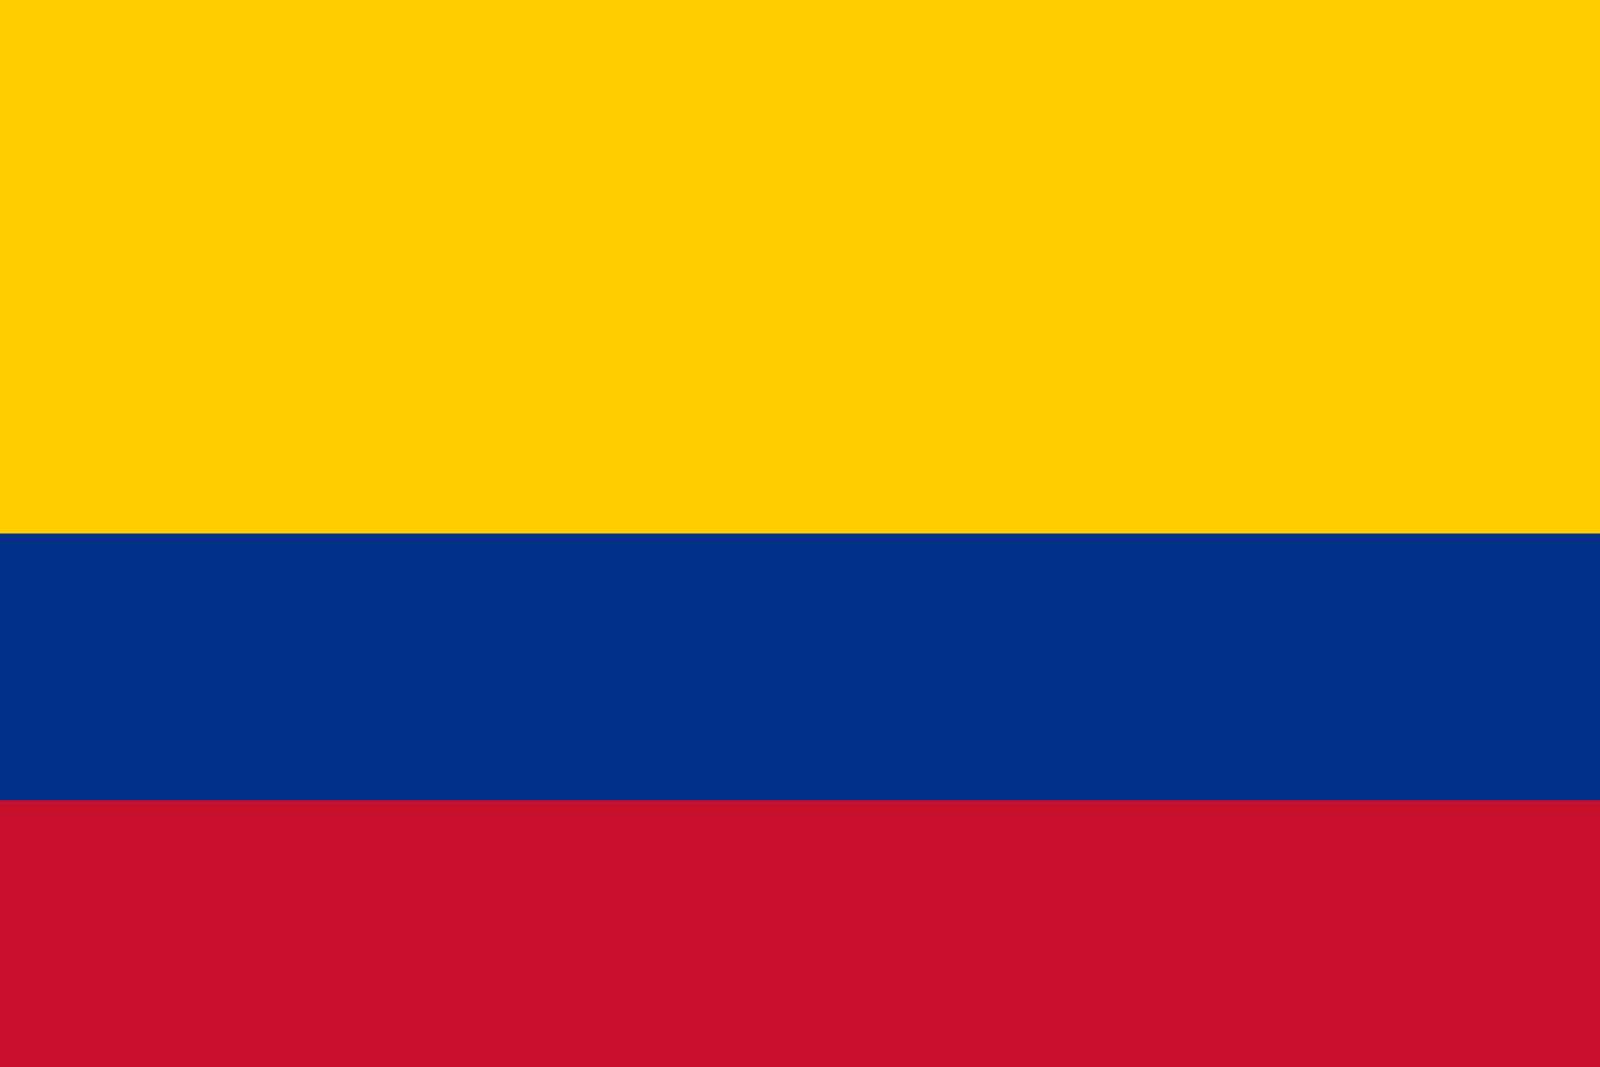

> Para el análisis se cuenta con 947,790 registros correspondientes a casos ocurridos en alguno de los 32 municipios y el distrito capital de la república de Colombia, representado en 19 variables, en el periodo del año 2013 al año 2023.

__________

In [1]:
# [Configuración] Importar librerías

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from statsmodels.graphics.tsaplots import plot_acf

# Geoespacial
import geopandas as gpd
from libpysal.weights import Queen
import libpysal
from esda.moran import Moran, Moran_Local

# Estadística clásica y no paramétrica
from scipy import stats
from scipy.stats import chi2_contingency, kruskal, shapiro
import scikit_posthocs as sp  # Pruebas post-hoc como Dunn

# Series temporales y detección de rupturas
import ruptures as rpt
from pymannkendall import original_test  # Tendencias en series temporales

In [2]:
# [Configuración] Leer data
df = pd.read_csv(r"C:\Users\Hp\DENGUE\DATA\Data_Colombia.csv")

# Leer shapefile
gdf = gpd.read_file("Mapas/Departamento/MGN_ADM_DPTO_POLITICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'dpto_cnmbr': 'departamento'})

semanas = pd.read_csv("Resumen/consolidado_colombia.csv")

casos = pd.read_csv("Resumen/casos_dep_colombia.csv")

poblacion = pd.read_csv("Poblacion/Poblacion_nacional.csv", encoding="latin_1")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947790 entries, 0 to 947789
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   sexo                   947790 non-null  object
 1   edad_años              947790 non-null  int64 
 2   ciclo_vital            947790 non-null  object
 3   grupo_etnico           947790 non-null  object
 4   regimen_salud          947790 non-null  object
 5   evento                 947790 non-null  object
 6   tipo_caso              947790 non-null  object
 7   hospitalizacion        947790 non-null  object
 8   desenlace              947790 non-null  object
 9   año                    947790 non-null  int64 
 10  semana                 947790 non-null  int64 
 11  periodo                947790 non-null  int64 
 12  fecha_inicio_sintomas  947737 non-null  object
 13  fecha_consulta         947697 non-null  object
 14  fecha_hospitalizacion  400804 non-null  object
 15  

In [3]:
# [] Convertir fechas a DateTime
columnas_fecha = ["fecha_consulta", "fecha_inicio_sintomas", "fecha_notificacion", "fecha_nacimiento", "fecha_hospitalizacion"]

for col in columnas_fecha:
    df[col] = df[col].replace(["--", "  -   -", "-", " "], pd.NA)
    df[col] = pd.to_datetime(df[col], format='mixed')
    print(f"Columna '{col}' convertida a datetime.")

Columna 'fecha_consulta' convertida a datetime.
Columna 'fecha_inicio_sintomas' convertida a datetime.
Columna 'fecha_notificacion' convertida a datetime.
Columna 'fecha_nacimiento' convertida a datetime.
Columna 'fecha_hospitalizacion' convertida a datetime.


In [4]:
# [] Valores nulos por variable
faltantes = df.isnull().sum()
print("Valores faltantes por variable: \n")
print(faltantes[faltantes > 0])

Valores faltantes por variable: 

fecha_inicio_sintomas        53
fecha_consulta               93
fecha_hospitalizacion    546986
fecha_nacimiento          30088
dtype: int64


## **1. Descriptivo de variables**

In [5]:
# [Función] Descripción de variables categóricas

def describir_categorica(columna, col_evento="evento"):
    tabla = pd.DataFrame({
        "Conteo": columna.value_counts(dropna=False),
        "Proporción": columna.value_counts(normalize=True, dropna=False).round(4)
    })

    tabla.index = tabla.index.map(lambda x: "NaN" if pd.isna(x) else x)
    crosstab_evento = pd.crosstab(df[columna.name], df[col_evento])
    tabla_completa = tabla.join(crosstab_evento)

    # Agregar proporciones específicas para 'Clasico' y 'Grave'
    if "Clasico" in crosstab_evento.columns:
        tabla_completa["Prop_Clasico"] = (tabla_completa["Clasico"] / tabla_completa["Conteo"]).round(4)
    else:
        tabla_completa["Prop_Clasico"] = 0
    if "Grave" in crosstab_evento.columns:
        tabla_completa["Prop_Grave"] = (tabla_completa["Grave"] / tabla_completa["Conteo"]).round(4)
    else:
        tabla_completa["Prop_Grave"] = 0

    print(f"\n📌 Variable: {columna.name}")
    print(tabla_completa)
    print("\n-----------------------------------")

### 2.1 Variables demográficas

In [6]:
print("DESCRIPCIÓN DE VARIABLES CATEGÓRICAS")
describir_categorica(df["ciclo_vital"])
describir_categorica(df["sexo"])
describir_categorica(df["grupo_etnico"])
describir_categorica(df["regimen_salud"])


DESCRIPCIÓN DE VARIABLES CATEGÓRICAS

📌 Variable: ciclo_vital
                  Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
ciclo_vital                                                                   
Adulto            354522      0.3741   350408   4114        0.9884      0.0116
Adolescencia      268126      0.2829   263627   4499        0.9832      0.0168
Infancia          154053      0.1625   150959   3094        0.9799      0.0201
Primera infancia  101852      0.1075   100013   1839        0.9819      0.0181
Adulto mayor       55679      0.0587    54696    983        0.9823      0.0177
Menor de 1 año      9056      0.0096     8679    377        0.9584      0.0416
Ancianidad          4497      0.0047     4391    106        0.9764      0.0236
Desconocido            5      0.0000        5      0        1.0000      0.0000

-----------------------------------

📌 Variable: sexo
           Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
sexo                 

De acuerdo a los registros, la población infectada por dengue en Colombia se encuentra, en mayor medida, en edad adulta (37.4%) o adolescente (28.2%). De los demás grupos, los menores de 1 año y ancianidad son los que proporcionalmente son los más afectados por el dengue grave.

El sexo de los pacientes se distribuye de forma equilibrada, siento el 52.3% masculinos. La pertenencia a grupos étnicas indica que solo el 5.08% pertenecen a algún grupo; cabe detallar que el más del 20% de los casos para población Indígena y Rom corresponden a dengue grave.

La afiliación a regimen de salud de la población es en su mayoría a regimen subsidiado (46.1%) o contributivo (44.4%), sin embargo, los pacientes no asegurados tienen una alta proporción de casos graves.

In [7]:
# [Análisis] Edad de los pacientes
df_edad = df[df["ciclo_vital"] != "Menor de 1 año"].copy()

orden_ciclos_edad = [
    "Primera infancia",
    "Infancia",
    "Adolescencia",
    "Adulto",
    "Adulto mayor",
    "Ancianidad"
]

df_edad["ciclo_vital"] = pd.Categorical(
    df_edad["ciclo_vital"], 
    categories=orden_ciclos_edad, 
    ordered=True
)

def tabla_descriptiva(df, variable, grupo=None):
    """
    Genera una tabla descriptiva (media, mediana, DE, IQR, etc.)
    por grupos (ej. ciclo vital).
    """
    if grupo:
        desc = df.groupby(grupo, observed=True)[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).reset_index()
    else:
        desc = df[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).to_frame().T
    return desc.round(2)

tabla = tabla_descriptiva(df_edad, variable="edad_años", grupo="ciclo_vital")
tabla

,ciclo_vital,n,media,mediana,sd,q25,q75,minimo,maximo
0,Primera infancia,101852,2.37,2.0,1.19,1.0,3.0,1,4
1,Infancia,154053,7.08,7.0,1.40,6.0,8.0,5,9
2,Adolescencia,268126,13.99,14.0,2.77,12.0,16.0,10,19
3,Adulto,354522,34.87,33.0,11.16,25.0,43.0,20,59
4,Adulto mayor,55679,69.09,68.0,6.79,63.0,74.0,60,84
5,Ancianidad,4497,88.89,88.0,4.25,86.0,91.0,85,131


La edad de los pacientes, diferenciada entre grupos etarios, se distribuye de la siguiente manera: 

* Primera infancia [1-4 años]: Mayor concentración de edades al rededor de los 2 años.
* Infancia [5-9 años]: Edad concentrada entre los 6-8 años.
* Adolescencia [10-19 años]: Mayor cantidad de pacientes entre los 12-16 años.
* Adulto [20-59 años]: Mayoría de pacientes entre los 25-43 años.
* Adulto mayor [60 - 84 años]: Edades entre los 63-74 años.
* Ancianidad [85 -131 años]: Concentración de edades entre los 86-91 años. 

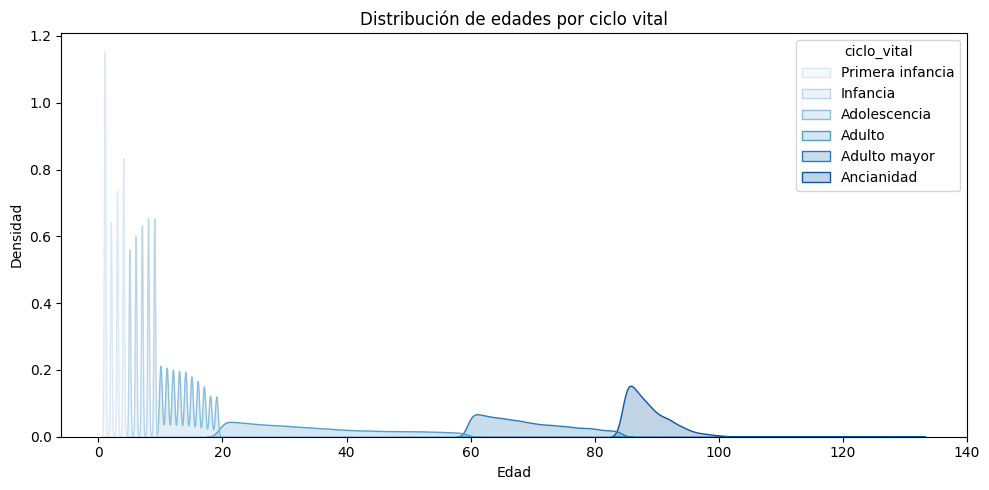

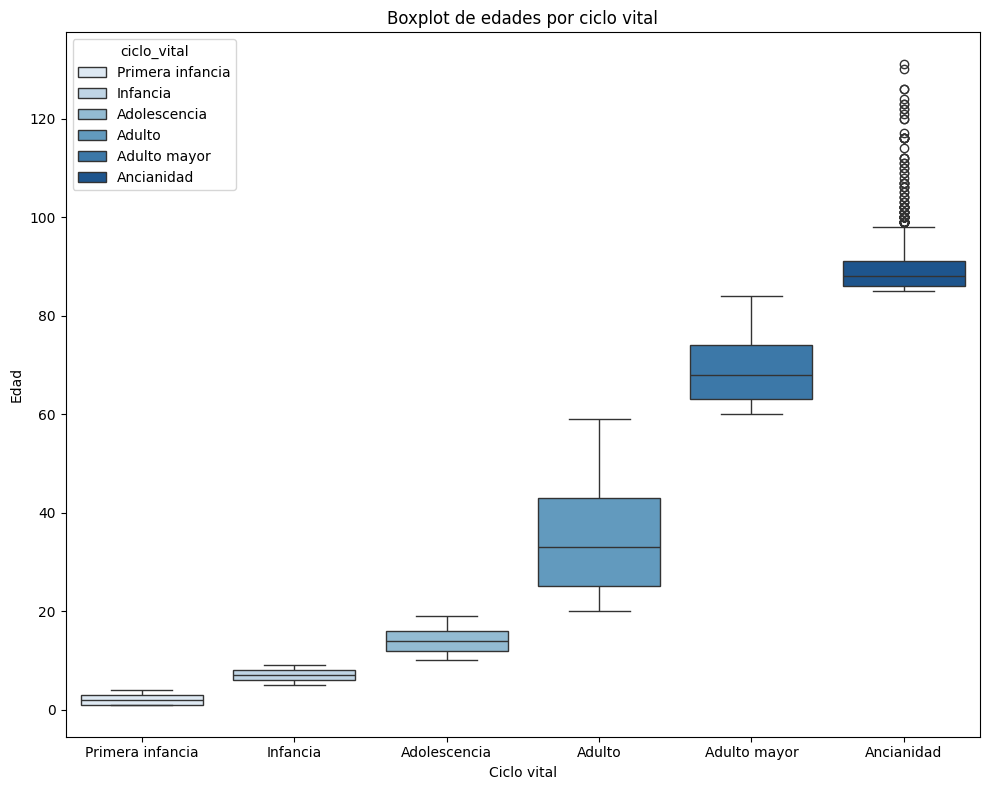

In [8]:
# [Gráfico] Distribución de edad
def graficos(df, variable, grupo):
    """
    Genera:
    1. Histograma + densidad global
    2. Densidad por ciclo vital
    3. Boxplot por ciclo vital
    """

    # --- 2. Densidad por ciclo vital ---
    plt.figure(figsize=(10,5))
    sns.kdeplot(data=df, x=variable, hue=grupo, common_norm=False, fill=True, palette="Blues")
    plt.title("Distribución de edades por ciclo vital")
    plt.xlabel("Edad")
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()

    # --- 3. Boxplot por ciclo vital ---
    plt.figure(figsize=(10,8))
    sns.boxplot(data=df, x=grupo, hue=grupo, y=variable, palette="Blues")
    plt.title("Boxplot de edades por ciclo vital")
    plt.xlabel("Ciclo vital")
    plt.ylabel("Edad")
    plt.tight_layout()
    plt.show()

graficos(df_edad, variable="edad_años", grupo="ciclo_vital")

Los gráficos representan la distribución de la edad, discriminada por grupos etarios, donde se evidencia que para las primeras etapas de la vida, la distribución de la edad de los pacientes es homogénea. La etapa adulta es la de mayor variabilidad, con un ligero sesgo positivo, lo que indica una mayor proporción de casos hacia los adultos mas jóvenes. Misma dinámica se aprecia para el grupo Adulto mayor y Ancianidad, en este último se presentan los casos de pacientes en edades atípicas. 

## Variables de evento

In [9]:
describir_categorica(df['evento'])
describir_categorica(df['tipo_caso'])
describir_categorica(df['hospitalizacion'])
describir_categorica(df['desenlace'])


📌 Variable: evento
         Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
evento                                                               
Clasico  932778      0.9842   932778      0           1.0         0.0
Grave     15012      0.0158        0  15012           0.0         1.0

-----------------------------------

📌 Variable: tipo_caso
                       Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
tipo_caso                                                                 
Probable               697800      0.7362   688277   9523        0.9864   
Conf. por laboratorio  241643      0.2550   236199   5444        0.9775   
Conf. por nexo           8347      0.0088     8302     45        0.9946   

                       Prop_Grave  
tipo_caso                          
Probable                   0.0136  
Conf. por laboratorio      0.0225  
Conf. por nexo             0.0054  

-----------------------------------

📌 Variable: hospitalizacion
                 C

El virus del dengue en su manifestación clásica tiene una representatividad del 98.4% (932,778 casos) en el país, frente al reducido conjunto del 1.6% (15,012) casos graves. 

En su mayoría, los casos fueron catalogados como probables (73.6%), el restante fue confirmado por laboratorio o nexo epidemiológico. La mayor parte de los pacientes (57.7%) no requirió hospitalización, aunque de los 400,806 pacientes hospitalizados, el 34.1% fue debido al dengue grave. 

La tasa de fallecidos es de solo 339, en su mayoría a causa del dengue grave. 

### 2.3 Variables espaciales

In [10]:
describir_categorica(df["area"])
describir_categorica(df['departamento'])


📌 Variable: area
                    Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
area                                                                   
Cabecera municipal  779765      0.8227   767715  12050        0.9845   
Rural disperso       90096      0.0951    88575   1521        0.9831   
Centro Poblado       77929      0.0822    76488   1441        0.9815   

                    Prop_Grave  
area                            
Cabecera municipal      0.0155  
Rural disperso          0.0169  
Centro Poblado          0.0185  

-----------------------------------

📌 Variable: departamento
                                                    Conteo  Proporción  \
departamento                                                             
VALLE DEL CAUCA                                     159217      0.1680   
TOLIMA                                               81906      0.0864   
SANTANDER                                            77715      0.0820   
ANTIOQUIA              

In [11]:
# [Tabla] Casos por departamento
tabla_mun = df.groupby(["departamento", "año", "evento"]).size().reset_index(name="casos")


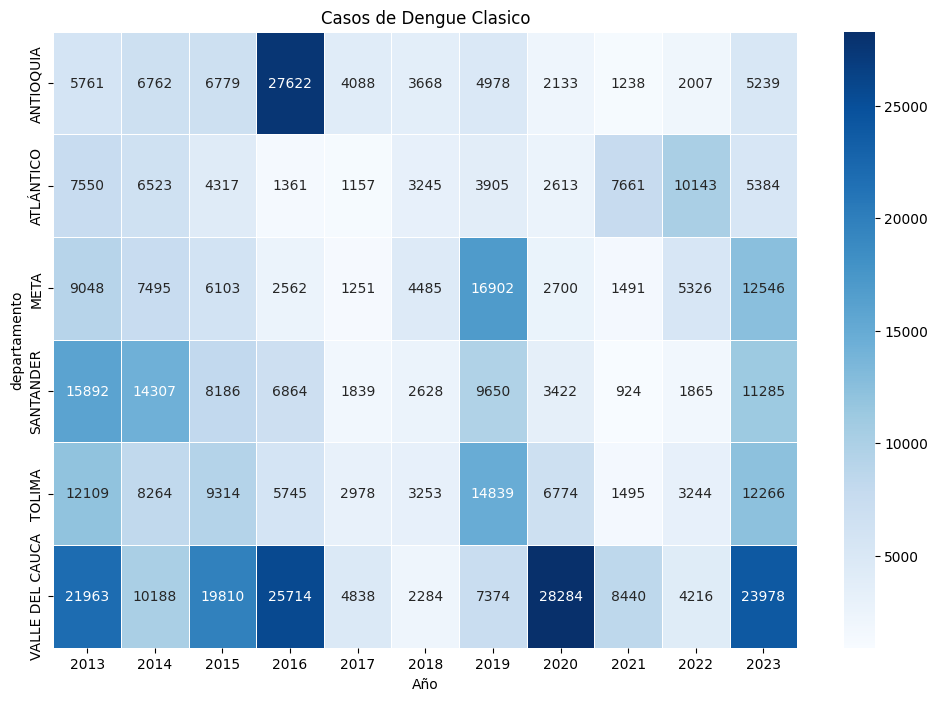

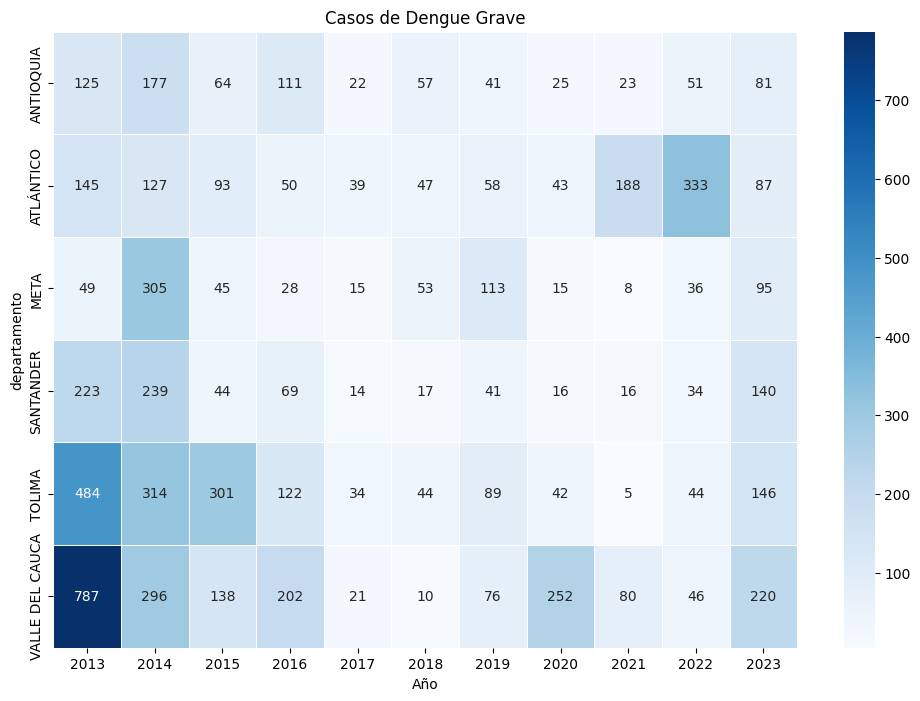

In [12]:
# [Gráfico] Tabla casos por departamento
totales_mun = tabla_mun.groupby("departamento")["casos"].sum()

departamentos_filtrados = totales_mun[totales_mun > 50000].index
tabla_filtrada = tabla_mun[tabla_mun["departamento"].isin(departamentos_filtrados)]

eventos = ["Clasico", "Grave"]

for evento in eventos:
    tabla_evento = tabla_filtrada[tabla_filtrada["evento"] == evento]

    # Crear tabla pivote
    pivot = tabla_evento.pivot_table(
        index="departamento", 
        columns="año", 
        values="casos", 
        fill_value=0
    ).astype(int)

    # Graficar
    plt.figure(figsize=(12,8))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.5, annot=True, fmt="d")
    plt.title(f"Casos de Dengue {evento}")
    plt.xlabel("Año")
    plt.ylabel("departamento")
    plt.show()


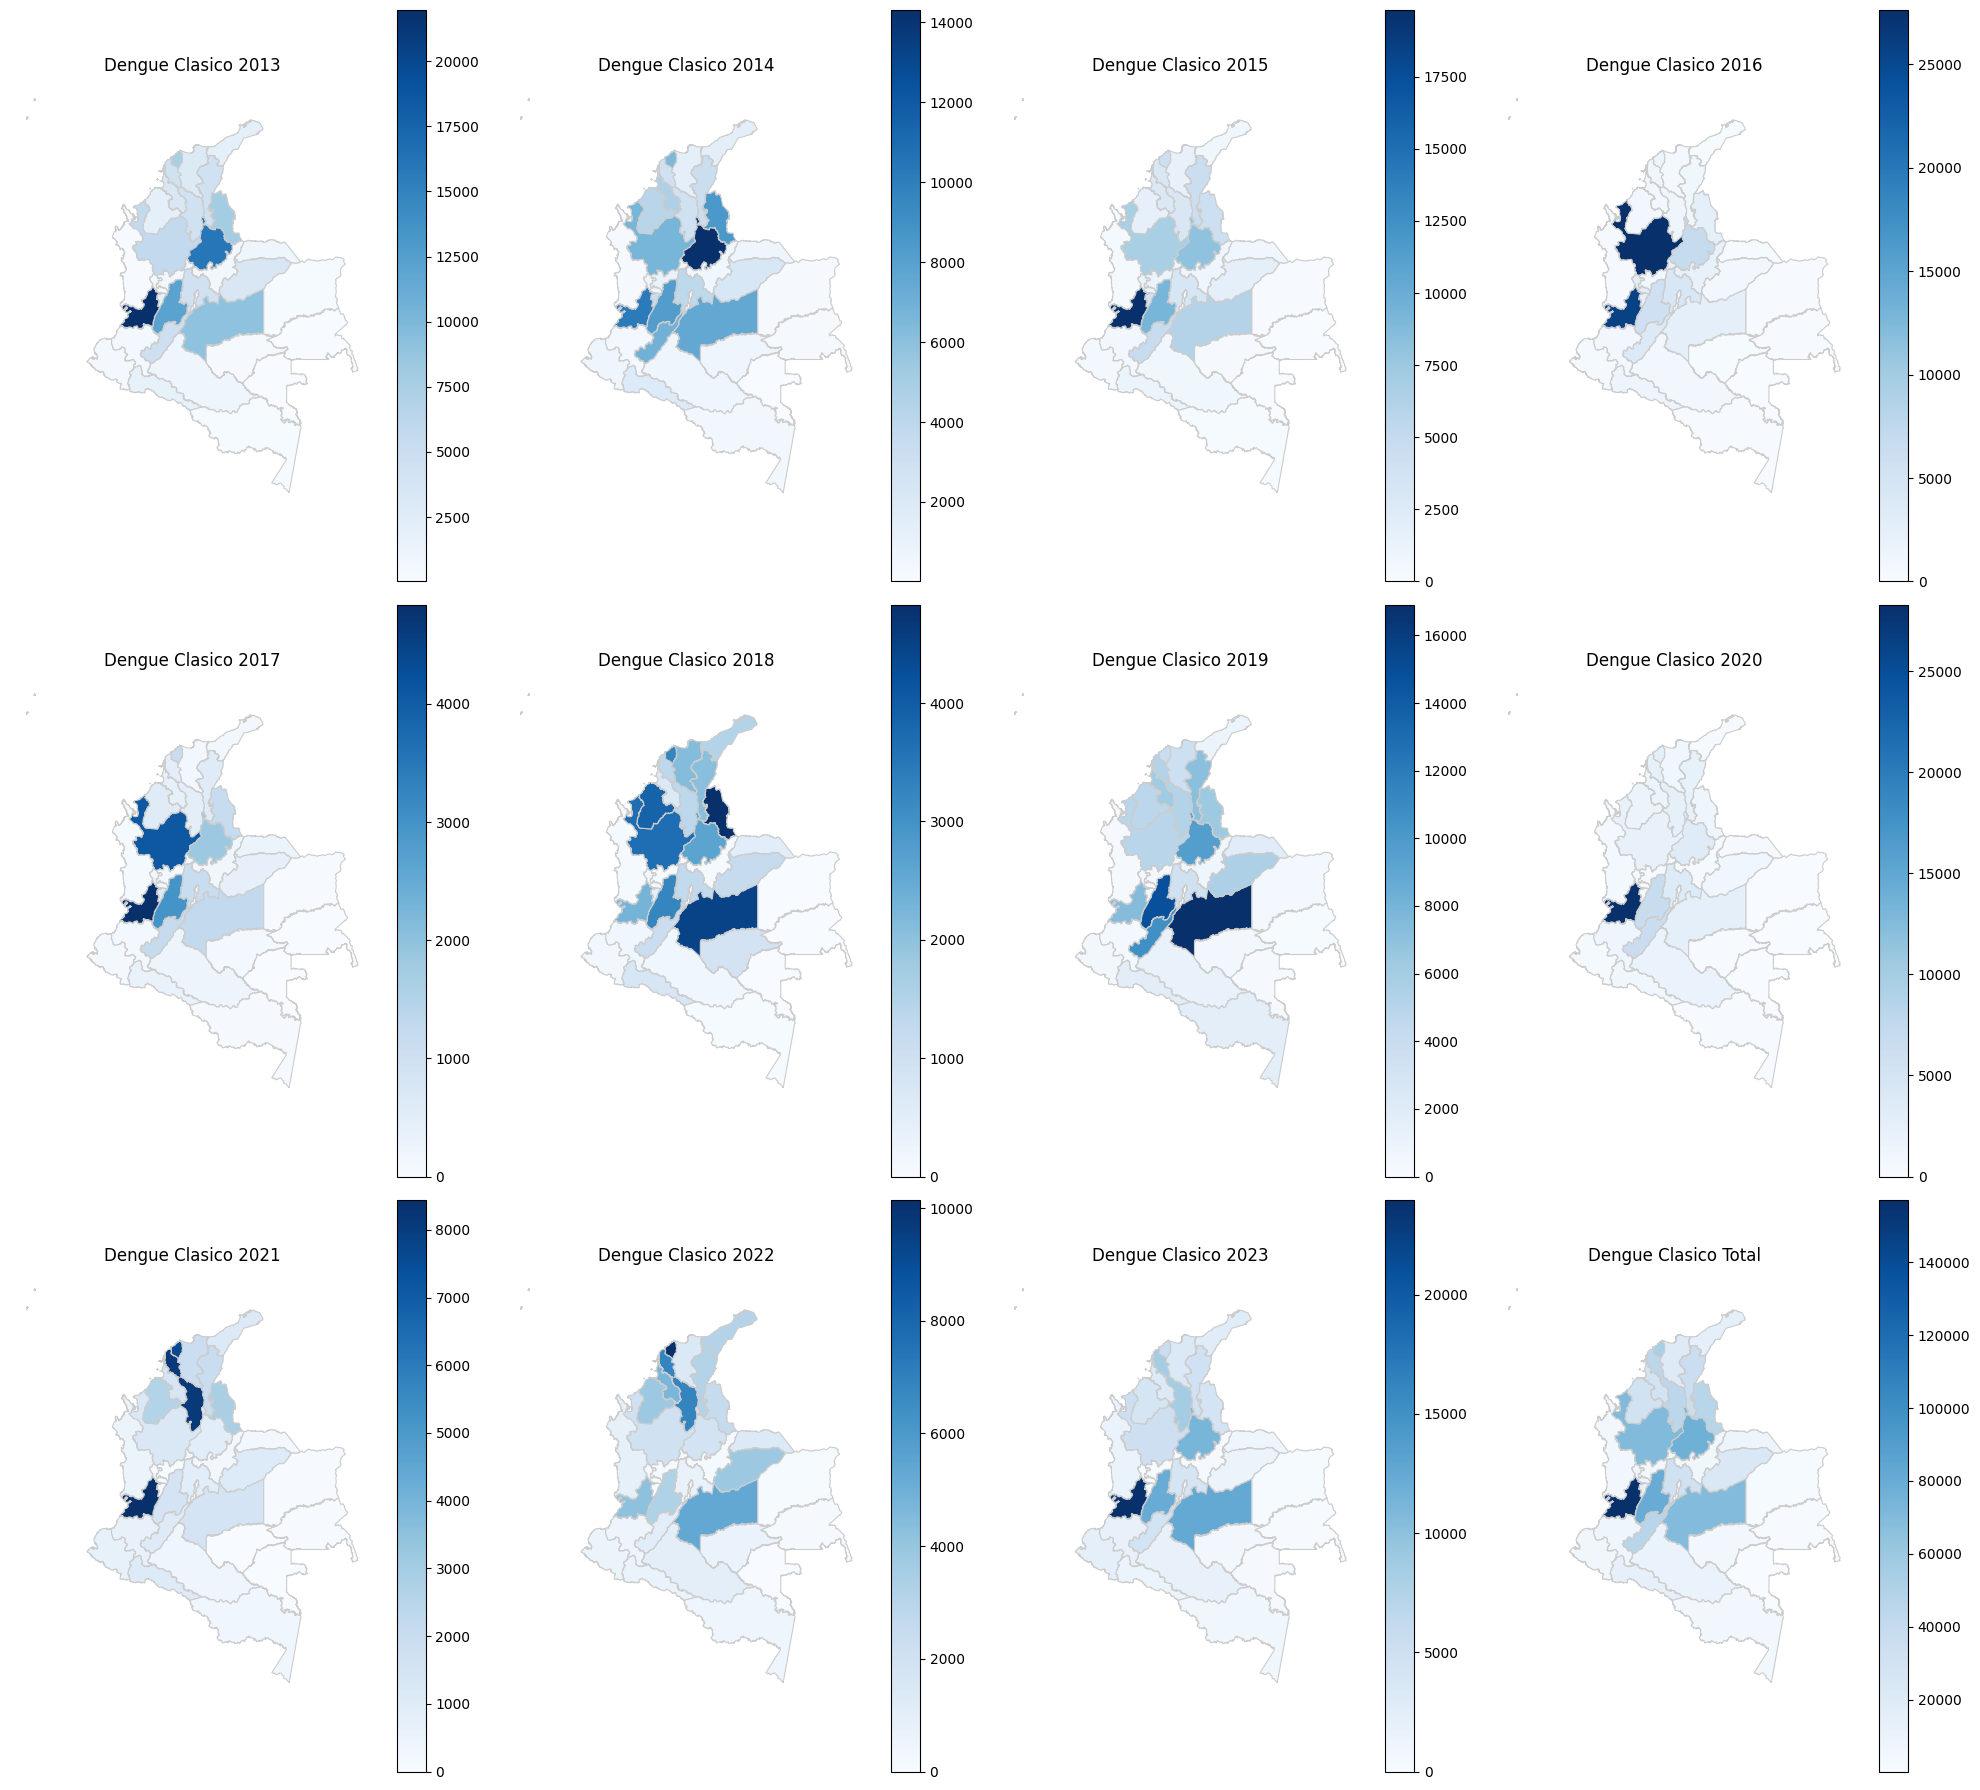

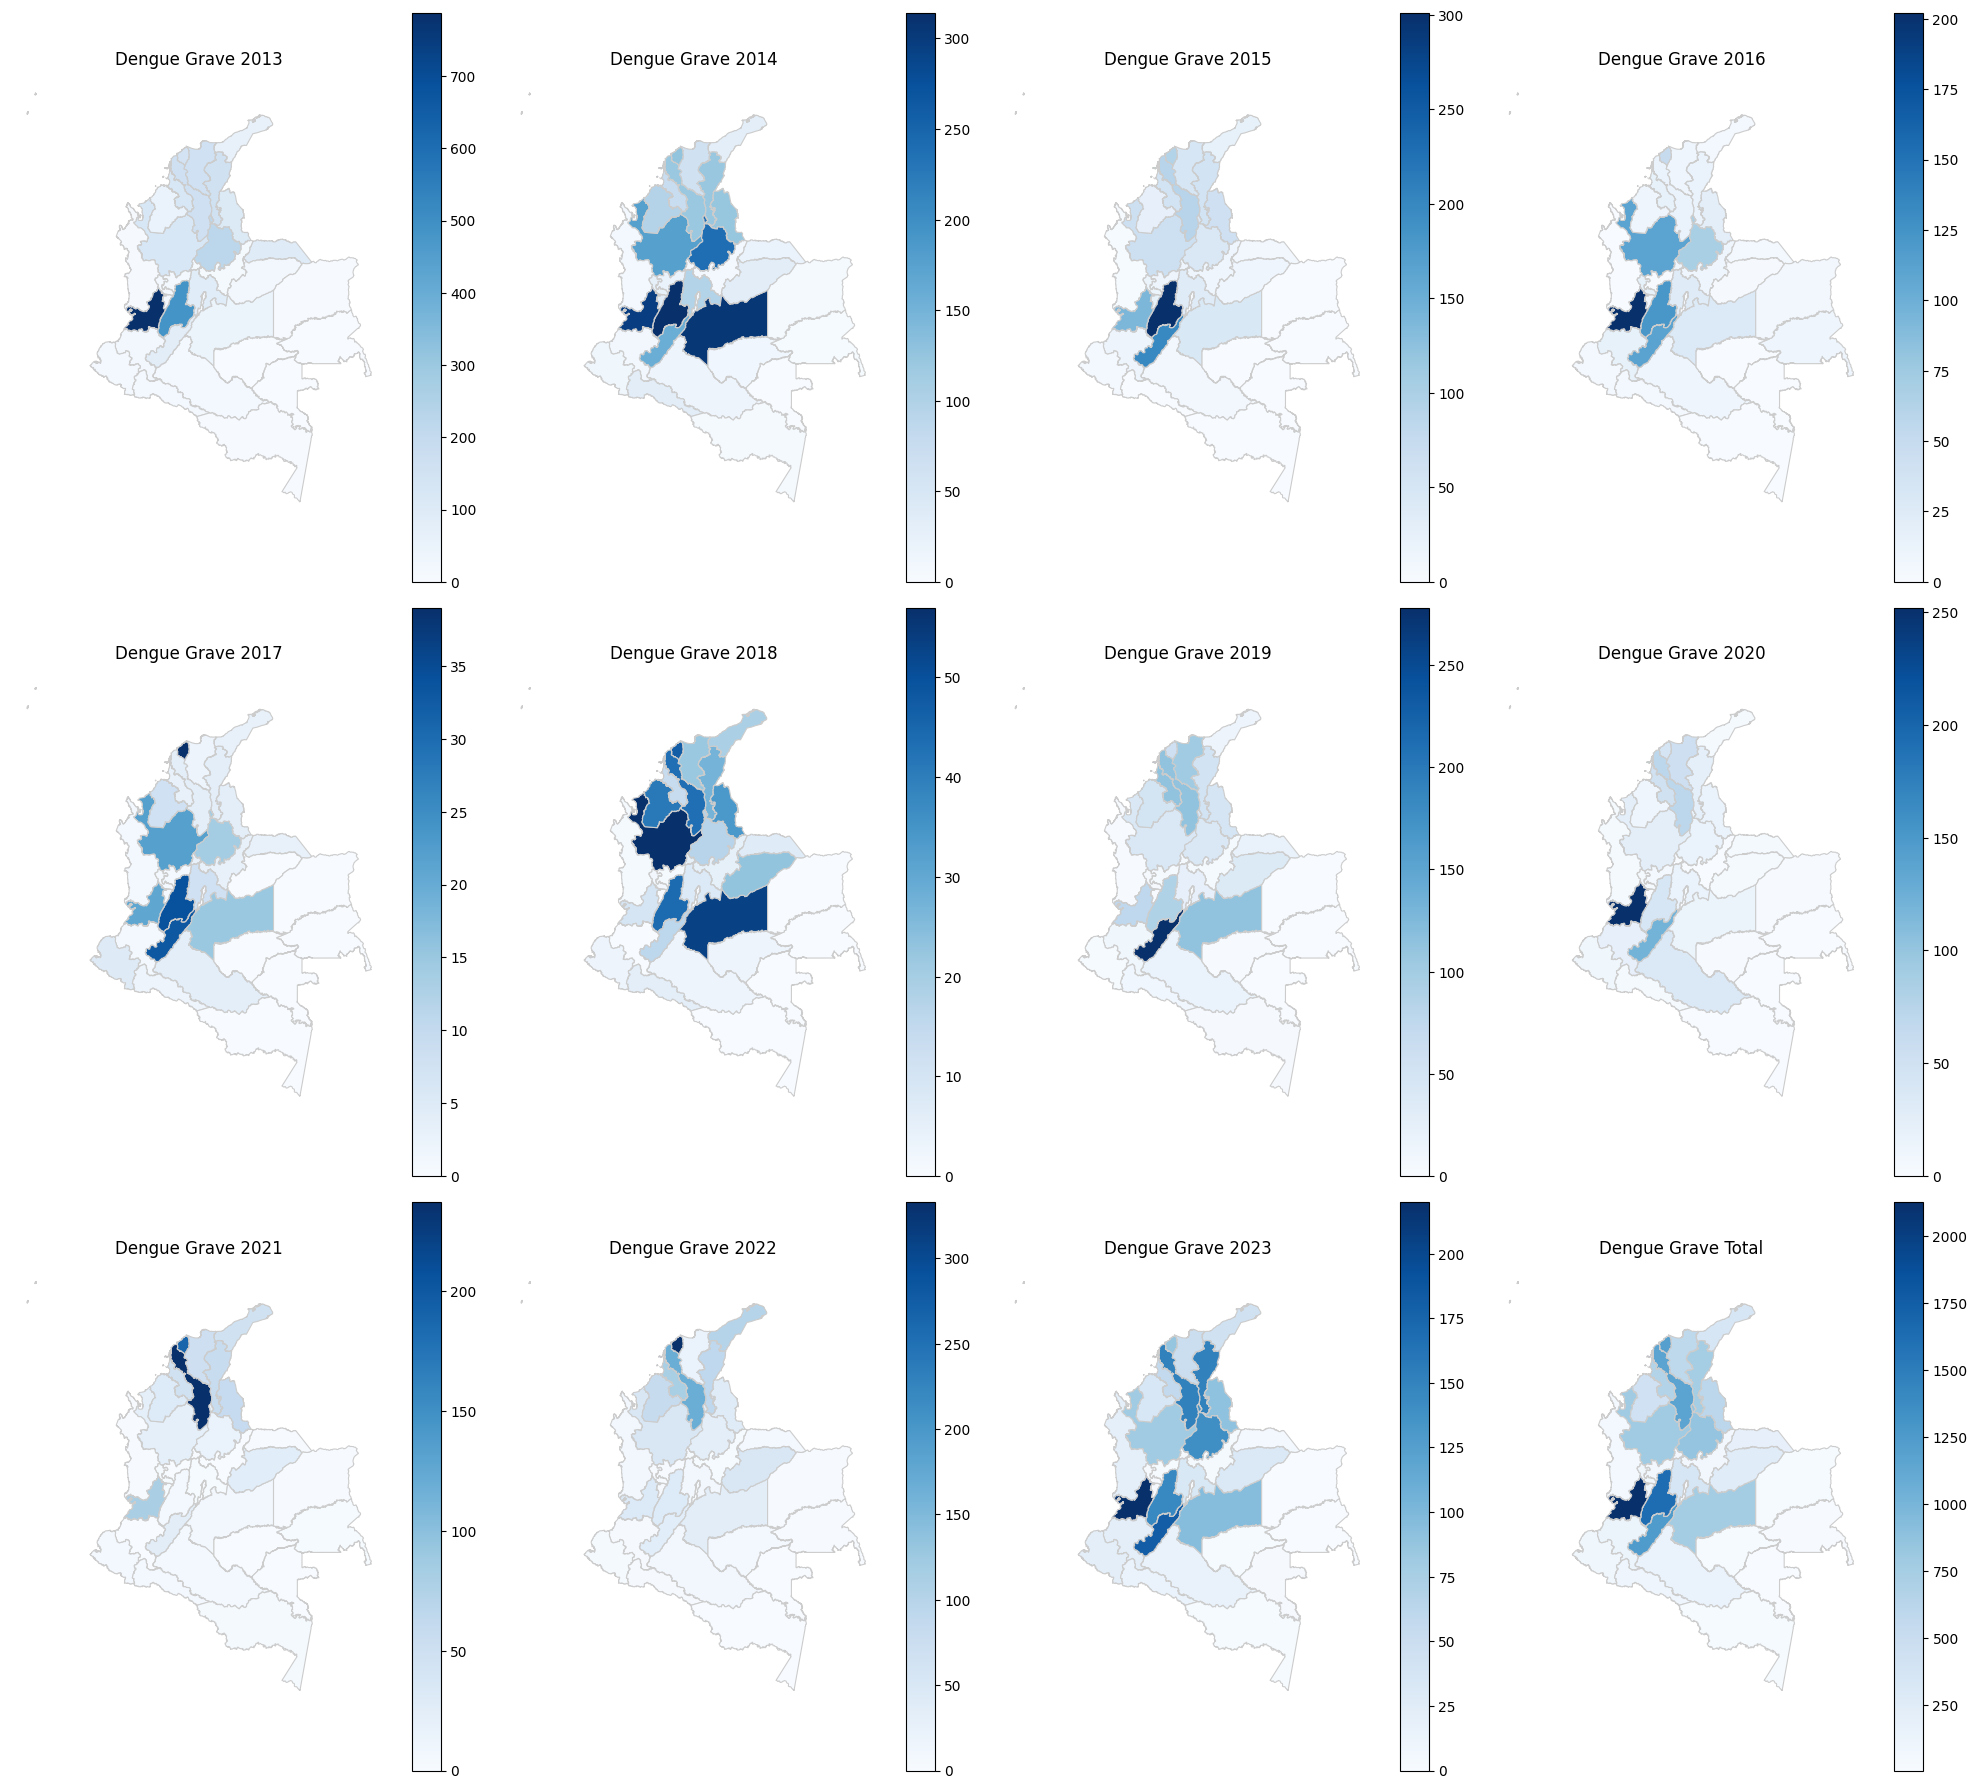

In [13]:
# [Gráfico] Mapa casos por departamento según evento

eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())
    n = len(anios) + 1  # años + total

    # Calcular número de filas y columnas dinámicamente
    columnas = 4
    filas = (n + columnas - 1) // columnas

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    # Mapas por año
    for i, anio in enumerate(anios):
        casos_anio = (
            df[(df["año"] == anio) & (df["evento"] == evento)]
            .groupby("departamento")
            .size()
            .reset_index(name="CASOS")
        )

        gdf_plot = gdf.merge(casos_anio, on="departamento", how="left").fillna(0)

        gdf_plot.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    # Mapa total por evento
    casos_total = (
        df[df["evento"] == evento]
        .groupby("departamento")
        .size()
        .reset_index(name="CASOS")
    )

    gdf_total = gdf.merge(casos_total, on="departamento", how="left").fillna(0)

    gdf_total.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                   legend=True, ax=axes[-1])
    axes[-1].set_title(f"Dengue {evento} Total")
    axes[-1].axis("off")

    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios) + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


Los casos de dengue se registraron en su mayoría en una cabecera municipal (82.3%), siendo el 9.5% en un centro poblado y el 8.2% en zona rural dispersa del territorio nacional. 

La dinámica por departamentos es variada, en datos netos, los departamentos de Valle del Cauca y Tolima registran la mayor cantidad de casos de dengue clásico y grave. Luego, los departamentos de Santander, Antioquia, Meta y Atlántico, terminan de constituir el bloque de departamentos con más de 50,000 casos. Cabe destacar que Valle del Cauca, Atlántico, Huila y Bolívar registran más de 1,000 casos por dengue clásico. 

Con menor representatividad, sin superar los 1,000 casos, se encuentran los departamentos de Guainía, Archipielago de San Andrés, Vaupés y la capital Bogotá.

#### Casos por densidad poblacional

In [14]:
# [Tabla] Casos por departamento
tabla_mun = df.groupby(["departamento", "año", "evento"]).size().reset_index(name="casos")

# Ajustar nombres de columna para unir
poblacion = poblacion.rename(columns={'DEPARTAMENTO':'departamento', 'TOTAL':'total_pob'})

# Convertir columnas de año en una columna 'año'
poblacion_long = poblacion.melt(
    id_vars=['departamento', 'total_pob'],    # mantener departamento y total
    value_vars=['2013.0', '2014.0', '2015.0', '2016.0', '2017.0','2018.0',
        '2019.0','2020.0','2021.0','2022.0','2023.0'],
    var_name='año',
    value_name='poblacion'
)

# Asegurarse de que 'año' sea numérico
poblacion_long['año'] = poblacion_long['año'].astype(float).astype(int)

# Unir casos con población del mismo año
tabla_mun = tabla_mun.merge(poblacion_long, on=['departamento','año'], how='left')

# Densidad por año y departamento
tabla_mun['densidad'] = tabla_mun['casos'] / tabla_mun['poblacion']

# Si quieres por cada 1000 habitantes
tabla_mun['densidad'] = (tabla_mun['casos'] / tabla_mun['poblacion']) * 10000

tabla_mun = tabla_mun.sort_values(by='densidad', ascending=False)

In [15]:
tabla_mun.head()

,departamento,año,evento,casos,total_pob,poblacion,densidad
9,AMAZONAS,2019,Clasico,1713,842716.0,78065.0,219.432524
429,META,2019,Clasico,16902,11479079.0,1062355.0,159.099359
200,CASANARE,2019,Clasico,5591,4642400.0,430549.0,129.857461
16,AMAZONAS,2023,Clasico,1004,842716.0,83087.0,120.837195
437,META,2023,Clasico,12546,11479079.0,1131202.0,110.908573


In [16]:
# Densidad global por departamento (todos los años)
densidad_global = tabla_mun.groupby("departamento").agg(
    casos_totales=('casos', 'sum'),
    poblacion_total=('total_pob', 'first')   # la misma población total por municipio
).reset_index()

densidad_global['densidad_global'] = (densidad_global['casos_totales'] / densidad_global['poblacion_total']) * 100000

# Ordenar de mayor a menor
densidad_global = densidad_global.sort_values(by='densidad_global', ascending=False)

densidad_global.head(10)


,departamento,casos_totales,poblacion_total,densidad_global
21,META,70671,11479079.0,615.650437
0,AMAZONAS,4870,842716.0,577.893383
30,TOLIMA,81906,14734749.0,555.869666
17,GUAVIARE,4676,889614.0,525.621224
10,CASANARE,23437,4642400.0,504.846631
18,HUILA,48034,12159495.0,395.032853
25,PUTUMAYO,13442,3828699.0,351.085316
31,VALLE DEL CAUCA,159217,49575463.0,321.160894
28,SANTANDER,77715,24224224.0,320.815230
2,ARAUCA,8943,2828826.0,316.138214


In [17]:
densidad_global['densidad_global'].describe()

count     32.000000
mean     236.205205
std      173.361032
min        0.382692
25%      100.286473
50%      192.161615
75%      320.901646
max      615.650437
Name: densidad_global, dtype: float64

<Axes: xlabel='densidad_global'>

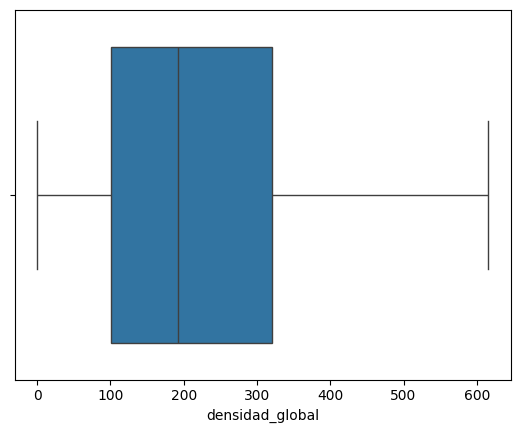

In [18]:
sns.boxplot(data=densidad_global, x='densidad_global')

La densidad poblacional de casos de dengue por departamento variable. En promedio, cada departamento reporta 236.20 casos por cada 100,000 habitantes, con una desviación estándar alta de 173.3 casos, indicando variaciones en la concentración de casos por departamento. La mitad de los departamentos reporta a lo más 192.1 casos, evidenciando que la densidad de casos se concentra en valores bajos, con una distribución sesgada a la derecha. 

El departamento de Meta es el de mayor densidad de casos de dengue reportando 615.65 casos por cada 100,000 habitantes. Sumado a ello, encontramos el bloque de departamentos con una densidad de más de 500 casos conformado por Amazonas, Tolima, Guaviare y Casanare.

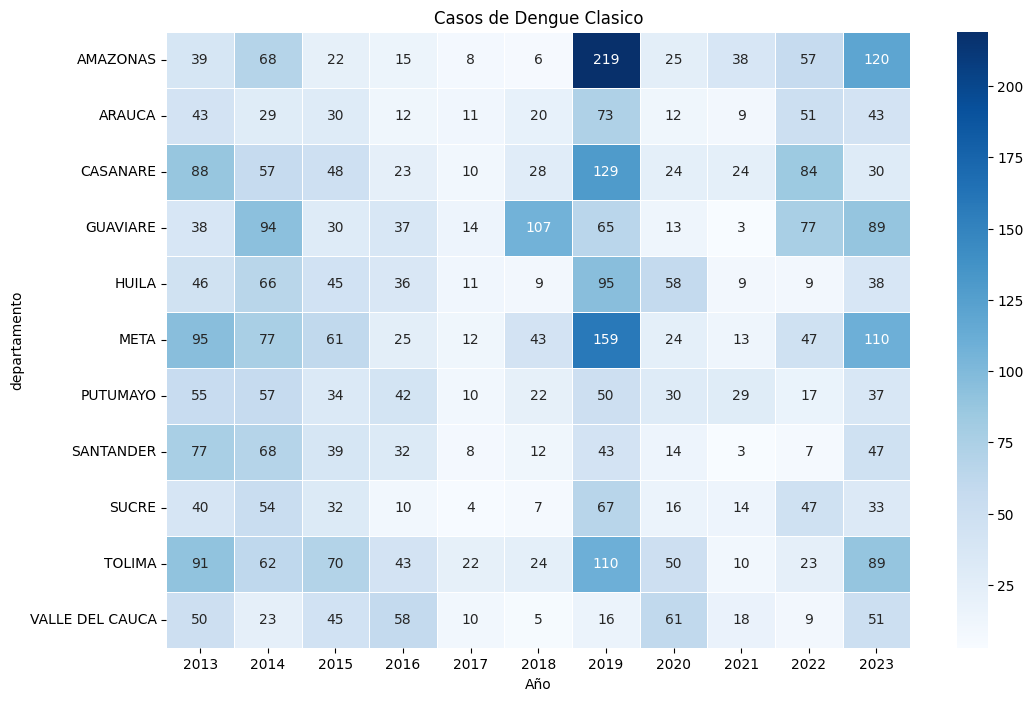

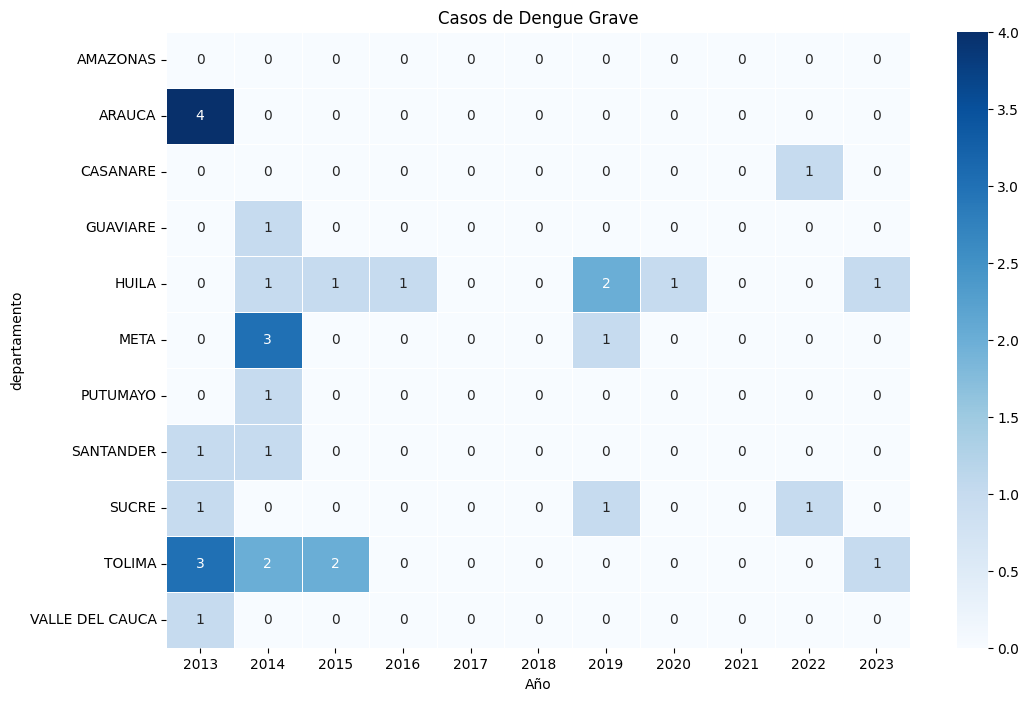

In [19]:
totales_mun = tabla_mun.groupby("departamento")["densidad"].sum()
departamentos_filtrados = totales_mun[totales_mun > 320].index
tabla_filtrada = tabla_mun[tabla_mun["departamento"].isin(departamentos_filtrados)]

eventos = ["Clasico", "Grave"]

for evento in eventos:
    tabla_evento = tabla_filtrada[tabla_filtrada["evento"] == evento]
    # Crear tabla pivote
    pivot = tabla_evento.pivot_table(
        index="departamento", 
        columns="año", 
        values="densidad", 
        fill_value=0
    ).astype(int)

    # Graficar
    plt.figure(figsize=(12,8))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.5, annot=True, fmt="d")
    plt.title(f"Casos de Dengue {evento}")
    plt.xlabel("Año")
    plt.ylabel("departamento")
    plt.show()


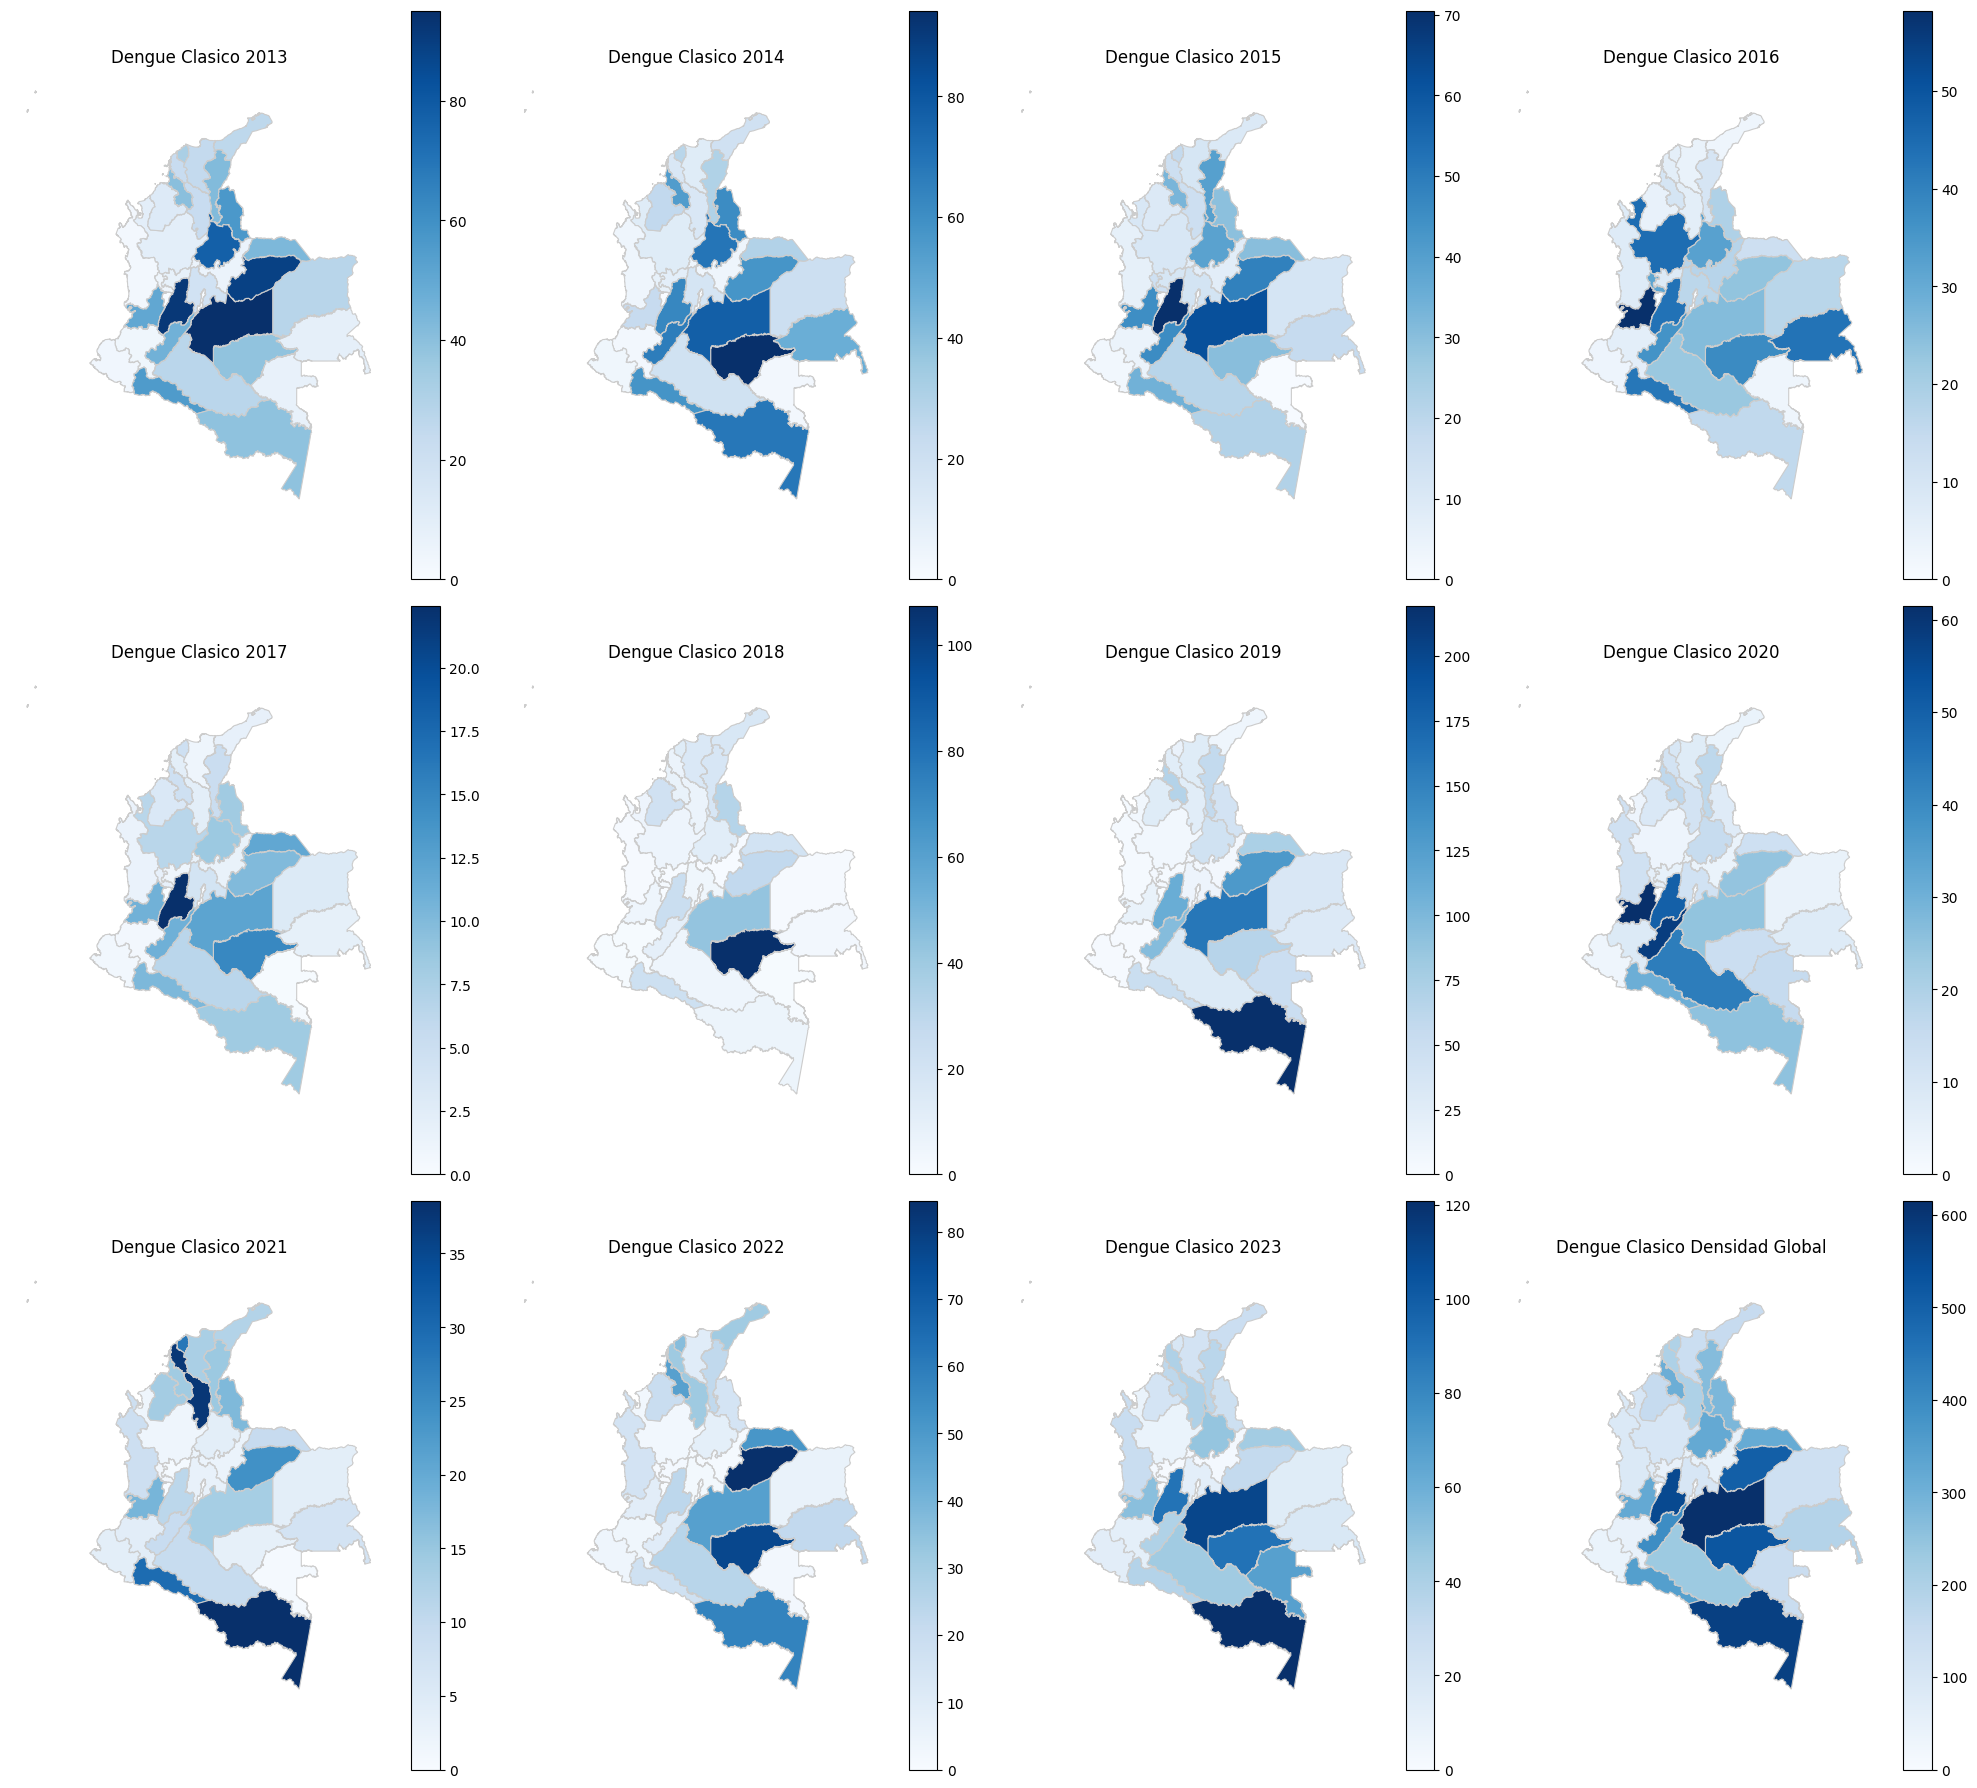

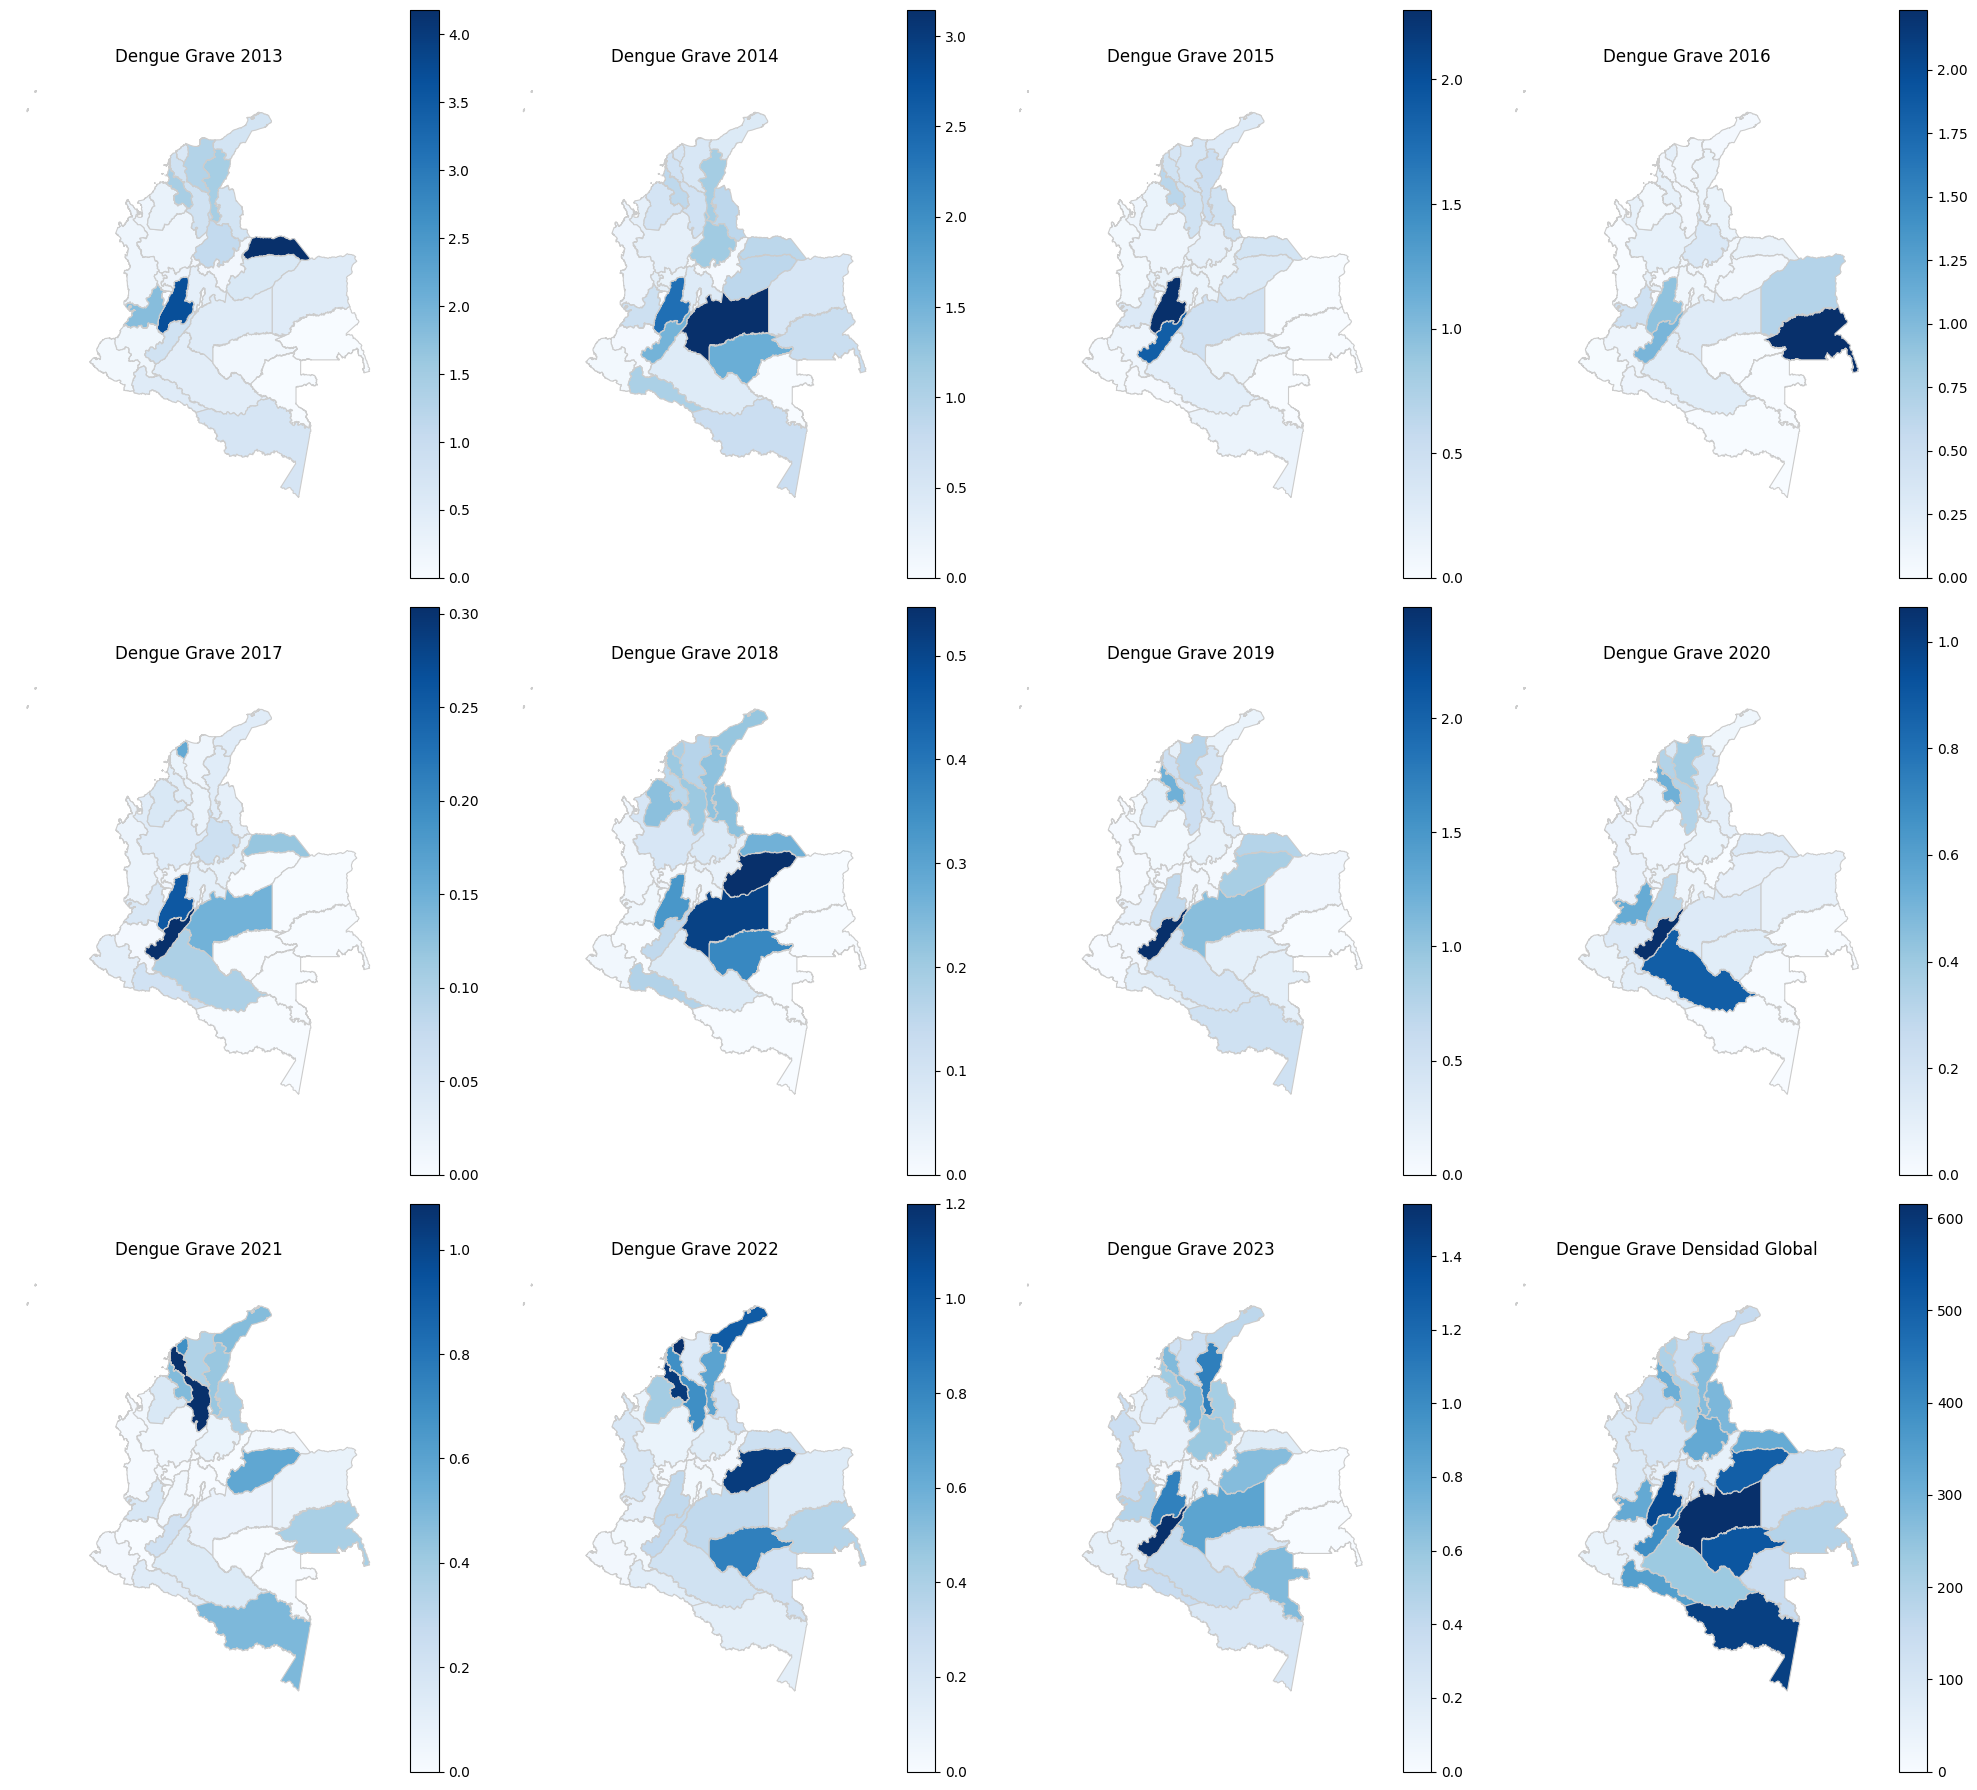

In [20]:
# [Gráfico] Mapa casos por departamento según evento

eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())
    n = len(anios) + 1  # años + total

    # Calcular número de filas y columnas dinámicamente
    columnas = 4
    filas = (n + columnas - 1) // columnas

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    # Mapas por año
    for i, anio in enumerate(anios):
        casos_anio = (
            tabla_mun[(tabla_mun["año"] == anio) & (tabla_mun["evento"] == evento)]
            .groupby("departamento")["densidad"].sum()   # sumar densidad por departamento
            .reset_index()
        )

        gdf_plot = gdf.merge(casos_anio, on="departamento", how="left").fillna(0)

        gdf_plot.plot(column="densidad", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    gdf_total = gdf.merge(densidad_global[['departamento','densidad_global']], on="departamento", how="left").fillna(0)
    gdf_total.plot(column="densidad_global", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                legend=True, ax=axes[-1])
    axes[-1].set_title(f"Dengue {evento} Densidad Global")
    axes[-1].axis("off")


    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios) + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


### 2.3 Variables temporales

In [21]:
describir_categorica(df["año"])


📌 Variable: año
      Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
año                                                               
2023  128101      0.1352   126381   1720        0.9866      0.0134
2013  125550      0.1325   122441   3109        0.9752      0.0248
2019  124942      0.1318   123594   1348        0.9892      0.0108
2014  107930      0.1139   105311   2619        0.9757      0.0243
2016  100970      0.1065   100071    899        0.9911      0.0089
2015   96401      0.1017    94980   1421        0.9853      0.0147
2020   77241      0.0815    76379    862        0.9888      0.0112
2022   67003      0.0707    65664   1339        0.9800      0.0200
2021   50244      0.0530    49304    940        0.9813      0.0187
2018   44156      0.0466    43637    519        0.9882      0.0118
2017   25252      0.0266    25016    236        0.9907      0.0093

-----------------------------------


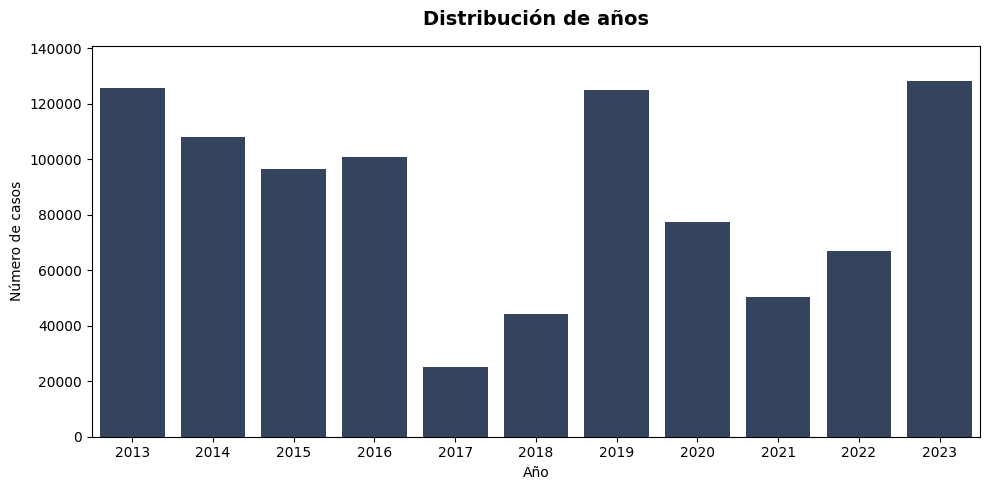

In [22]:
# [Gráfico] Distribución por años
conteo_por_año = df['año'].value_counts(sort=False).sort_index()

    # Crear gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_por_año.index.astype(str), y=conteo_por_año.values, color='#2E4265')

plt.title('Distribución de años', fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.ylim(0, max(conteo_por_año.values) * 1.1)
plt.tight_layout()
plt.show()


La variabilidad de los casos en el tiempo, muestra una tendencia cambiante al pasar de los años, en los primeros 3 años de registro, existe una tendencia a la baja, con una caída abrupta hacia el 2017, que luego se recupera con un pico en el 2019, volviendo a repetirse el patrón del 2020 al 2023, donde se tuvo la menor cantidad de registros en el 2021. 

La mayor cantidad de casos de dengue se reportan en los años 2013, 2019 y 2023, representando cada uno un más del 13% del total de registros. El 2013 fue el año con mayor cantidad de casos por dengue grave reportado, con más de 3,100 eventos, seguido del 2014 con 2,619 casos.

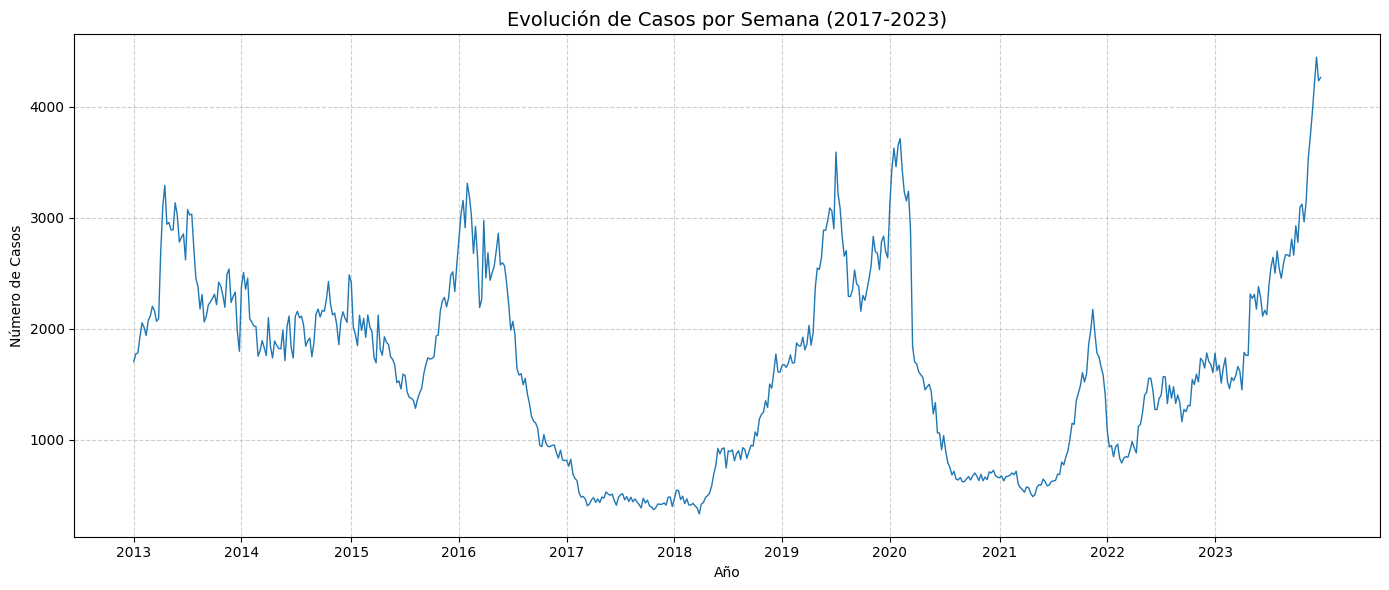

In [23]:
# [Gráfico] Casos por semana
casos_semana = df.groupby(["año", "semana"]).size().reset_index(name="casos")
casos_semana = casos_semana.sort_values(["año", "semana"]).reset_index(drop=True)
casos_semana["index"] = range(len(casos_semana))

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(casos_semana["index"], casos_semana["casos"], linewidth=1)
años_unicos = casos_semana["año"].unique()
ticks = [casos_semana[casos_semana["año"] == año].index[0] for año in años_unicos]
plt.xticks(ticks, años_unicos, fontsize=10)
plt.title("Evolución de Casos por Semana (2017-2023)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Número de Casos")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [24]:
week = tabla_descriptiva(df_edad, variable="semana", grupo="año")
week

,año,n,media,mediana,sd,q25,q75,minimo,maximo
0,2013,124071,26.62,26.0,14.17,15.0,39.0,1,52
1,2014,106615,27.19,28.0,15.66,13.0,41.0,1,53
2,2015,95110,26.86,26.0,15.99,12.0,42.0,1,52
3,2016,100244,20.47,19.0,13.61,9.0,30.0,1,52
4,2017,24955,24.50,24.0,15.46,10.0,38.0,1,52
5,2018,43678,32.67,35.0,14.46,22.0,45.0,1,52
6,2019,123909,28.30,28.0,14.27,18.0,41.0,1,52
7,2020,76640,17.49,12.0,14.42,6.0,26.0,1,53
8,2021,49764,32.79,38.0,15.07,21.0,45.0,1,52
9,2022,66465,29.33,30.0,14.60,18.0,42.0,1,52


C:\Users\Hp\AppData\Local\Temp\ipykernel_19392\1452467844.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = cm.get_cmap('Blues', len(años))  # paleta con N tonos


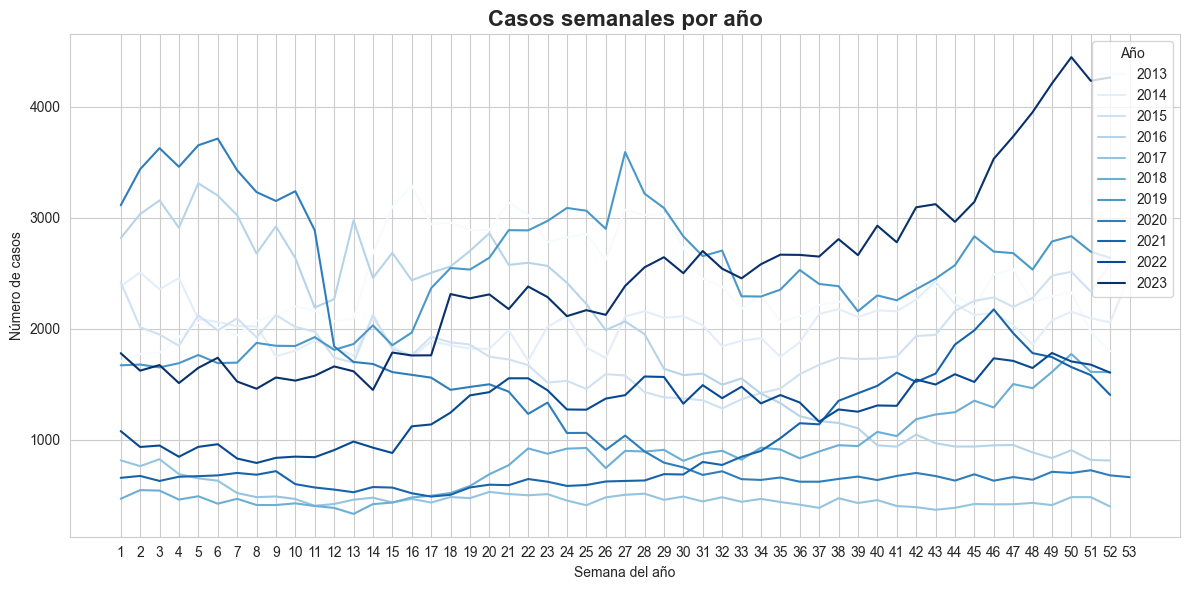

In [25]:
# Contar casos por semana y año
conteo_semanal = df.groupby(['año', 'semana']).size().reset_index(name='casos')

def graficar_casos_semanales_por_año(df_conteo, nombre_grafico="Casos semanales por año"):
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    años = sorted(df_conteo['año'].unique())
    colores = cm.get_cmap('Blues', len(años))  # paleta con N tonos

    for i, año in enumerate(años):
        datos_año = df_conteo[df_conteo['año'] == año]
        plt.plot(datos_año['semana'], datos_año['casos'], 
                label=str(año), color=colores(i))
        
    plt.title(nombre_grafico, fontsize=16, fontweight='bold')
    plt.xlabel("Semana del año")
    plt.ylabel("Número de casos")
    plt.xticks(range(1, 54))  # Semanas ISO van de 1 a 53
    plt.legend(title="Año")
    plt.tight_layout()
    plt.show()

graficar_casos_semanales_por_año(conteo_semanal)

Al evaluar los registros por semana epidemiológica, se evidencia un comportamiento variado a lo largo de los años. Del 2013 a mitad de 2016, se reportan entre 1500 a 3200 casos por semana, pasando a menos de 500 en el 2017. Los picos más altos de registros se encuentran en la mitad del 2019 e inicios del 2020, con más de 3,500 casos, el más alto, se da a finales del 2023 superando los 4,000 casos en una semana. 

De manera general, la mitad de los casos se reportaron entre la semana 14 y la semana 39. El año más variable fue el 2019, frente al 2017 el menos variable.


## **2. Exploración binaria**

In [26]:
demograficas = [
    "sexo",                    # M/F
    "edad_años",               # Edad numérica
    "ciclo_vital",             # Etapa de vida
    "grupo_etnico",            # Grupo étnico declarado
    "regimen_salud"            # Régimen (contributivo, subsidiado, etc.)
]

    # Variables del evento epidemiológico
evento = [
    "evento",                  # Clásico, grave
    "tipo_caso",               # Confirmado, probable, descartado
    "hospitalizacion",         # Sí/No
    "desenlace"                # Recuperado, fallecido, etc.
]

    # Variables de temporalidad
temporalidad = [
    "año",                     # Año del evento
    "semana",                  # Semana epidemiológica
    "periodo",                 # Periodo (cada 4 semanas)
    "fecha_inicio_sintomas",   # Inicio de síntomas
    "fecha_consulta",          # Fecha de consulta
    "fecha_hospitalizacion",   # Fecha de hospitalización
    "fecha_notificacion",      # Fecha de notificación
    "fecha_nacimiento"         # Fecha de nacimiento
]

    # Variables espaciales
espacial = [
    "departamento"                # Municipio de ocurrencia
    "area",                    # Urbana o rural
]

In [27]:
# [Test] Prueba de Chi-Cuadrado
def matriz_pvalores(df, variables, alpha=0.05):
    matriz = pd.DataFrame(index=variables, columns=variables)
    for var1 in variables:
        for var2 in variables:
            if var1 == var2:
                matriz.loc[var1, var2] = "-"
            else:
                tabla = pd.crosstab(df[var1], df[var2])
                if tabla.shape[0] > 1 and tabla.shape[1] > 1:
                    chi2, p, dof, exp = chi2_contingency(tabla)
                    matriz.loc[var1, var2] = round(p, 4)
                else:
                    matriz.loc[var1, var2] = None
    return matriz

In [28]:
# [Test] Prueba de Chi-cuadrado por categoría
def chi_por_categoria(df, variable_referencia, variables_comparar, alpha=0.05):
    categorias = df[variable_referencia].dropna().unique()
    resultados = []

    for categoria in categorias:
        fila = {"Categoría": categoria}
        for var in variables_comparar:
            if var == variable_referencia:
                fila[var] = "-"
                continue

            # Grupo A = categoría específica vs resto
            df_temp = df.copy()
            df_temp["grupo_vs_resto"] = df_temp[variable_referencia].apply(
                lambda x: categoria if x == categoria else f"No {categoria}"
            )

            tabla = pd.crosstab(df_temp["grupo_vs_resto"], df_temp[var])
            _, p, _, _ = chi2_contingency(tabla)
            test = "Chi²"

            simb = "★" if p <= alpha else ""
            fila[var] = f"{round(p,4)} {simb}"
        resultados.append(fila)

    return pd.DataFrame(resultados)

### Variables demográficas

In [29]:
demograficas_c = ["sexo", "ciclo_vital","grupo_etnico","regimen_salud"]

In [30]:
matriz_demo = matriz_pvalores(df[demograficas_c], demograficas_c)
matriz_demo

,sexo,ciclo_vital,grupo_etnico,regimen_salud
sexo,-,0.0,0.0,0.0
ciclo_vital,0.0,-,0.0,0.0
grupo_etnico,0.0,0.0,-,0.0
regimen_salud,0.0,0.0,0.0,-


De acuerdo a la prueba de Chi-cuadrado, todas las variables demográficas son dependientes entre sí, indicando relación entre los grupos.

In [31]:
tabla_sexo = chi_por_categoria(df, "sexo", demograficas_c)
tabla_sexo

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Masculino,-,0.0 ★,0.0 ★,0.0 ★
1,Femenino,-,0.0 ★,0.0 ★,0.0 ★


In [32]:
tabla_ciclo = chi_por_categoria(df, "ciclo_vital", demograficas_c)
tabla_ciclo

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Adulto mayor,0.0 ★,-,0.0 ★,0.0 ★
1,Adulto,0.001 ★,-,0.0 ★,0.0 ★
2,Adolescencia,0.0 ★,-,0.0005 ★,0.0 ★
3,Ancianidad,0.9921,-,0.4728,0.0 ★
4,Infancia,0.0 ★,-,0.0 ★,0.0 ★
5,Menor de 1 año,0.4896,-,0.0297 ★,0.0 ★
6,Primera infancia,0.0 ★,-,0.0 ★,0.0 ★
7,Desconocido,0.9146,-,0.966,0.9829


In [33]:
tabla_salud = chi_por_categoria(df, "regimen_salud", demograficas_c)
tabla_salud

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Subsidiado,0.0 ★,0.0 ★,0.0 ★,-
1,Contributivo,0.0 ★,0.0 ★,0.0 ★,-
2,Excepción,0.0 ★,0.0 ★,0.0 ★,-
3,Especial,0.0 ★,0.0 ★,0.0 ★,-
4,No asegurado,0.0 ★,0.0 ★,0.0 ★,-
5,Indeterminado,0.2143,0.0 ★,0.0 ★,-


Cada variable demográfica es dependiente del sexo del paciente. Solo los menores a un año y los ancianos, y los pacientes de regimen de salud indeterminado no dependen de ello. 

En el regimen de salud, esta estrechamente dependiente de la edad de los pacientes, asi como la pertenencia a un grupo étnico. 

In [34]:
categoricas = ["sexo", "ciclo_vital","grupo_etnico","regimen_salud", 
                "tipo_de_caso", "hospitalizacion","desenlace"]
tabla_evento = chi_por_categoria(df, "evento", demograficas_c)
tabla_evento

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Clasico,0.4796,0.0 ★,0.0 ★,0.0 ★
1,Grave,0.4796,0.0 ★,0.0 ★,0.0 ★


La prueba de Chi-Cuadrado de independencia entre el evento de dengue y las variables demográficas muestra que ambos casos de evento están significativamente relacionados a todas las variables demográficas.

### Variables de evento

In [35]:
matriz_eve= matriz_pvalores(df[evento], evento)
matriz_eve

,evento,tipo_caso,hospitalizacion,desenlace
evento,-,0.0,0.0,0.0
tipo_caso,0.0,-,0.0,0.4942
hospitalizacion,0.0,0.0,-,0.0
desenlace,0.0,0.4942,0.0,-


Con respecto a las variables relacionadas con el evento epidemiológico, solo el tipo de caso es estadísticamente independiente al desenlace del paciente. Del resto, el tipo de caso, la hospitalización y el desenlace del paciente son significativamente dependientes del evento de dengue.

### Variables temporales

In [36]:
# [Test] Shapiro para normalidad
stat, p = shapiro(semanas['total_casos'])
print(f"Estadístico={stat:.3f}, p-valor={p:.4f}")


Estadístico=0.961, p-valor=0.0000


Los casos de dengue por semana epidemiológica en Colombia, de acuerdo a la prueba Shapiro-Wilk, no siguen una distribución normal.

In [37]:
# [Test] Kruskall Wallys para correspondencia
def comparar_casos_por_año(df, num_var='casos', cat_var='año', alpha=0.05):

    grupos = [df[df[cat_var]==g][num_var] for g in df[cat_var].unique()]
    
    # Kruskal-Wallis
    stat, p = kruskal(*grupos)
    kruskal_res = pd.DataFrame({
        'Estadístico': [stat],
        'p-valor': [p],
        'Significativo': ["★" if p <= alpha else ""]
    })
    
    # Post-hoc Dunn (solo si hay más de 2 grupos)
    if len(df[cat_var].unique()) > 2:
        posthoc = sp.posthoc_dunn(df, val_col=num_var, group_col=cat_var, p_adjust='bonferroni')
    else:
        posthoc = None
    
    return {'kruskal': kruskal_res, 'posthoc': posthoc}


resultados = comparar_casos_por_año(semanas, num_var='total_casos', cat_var='año')

print("Kruskal-Wallis:")
resultados['kruskal']

Kruskal-Wallis:


,Estadístico,p-valor,Significativo
0,368.994218,3.690941e-73,★


In [38]:
print("\nDunn post-hoc (p-valores corregidos Bonferroni):")
resultados['posthoc']


Dunn post-hoc (p-valores corregidos Bonferroni):


,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
2013,1.000000e+00,1.000000e+00,2.513774e-02,1.477238e-01,5.266495e-34,3.504767e-21,1.000000e+00,5.123982e-09,1.076316e-17,3.293297e-11,1.000000e+00
2014,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.753248e-24,3.498944e-13,1.000000e+00,6.205312e-04,1.996408e-10,1.615975e-05,1.000000e+00
2015,2.513774e-02,1.000000e+00,1.000000e+00,1.000000e+00,1.552066e-17,1.164494e-08,5.030711e-02,1.712690e-01,1.963353e-06,1.204544e-02,2.371896e-01
2016,1.477238e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.417174e-19,3.901544e-10,2.704809e-01,2.950992e-02,9.949858e-08,1.473316e-03,1.000000e+00
2017,5.266495e-34,9.753248e-24,1.552066e-17,1.417174e-19,1.000000e+00,4.795651e-01,5.569410e-33,7.401822e-08,2.921311e-02,7.127116e-06,1.505902e-30
2018,3.504767e-21,3.498944e-13,1.164494e-08,3.901544e-10,4.795651e-01,1.000000e+00,2.265278e-20,3.362682e-02,1.000000e+00,4.341731e-01,1.845681e-18
2019,1.000000e+00,1.000000e+00,5.030711e-02,2.704809e-01,5.569410e-33,2.265278e-20,1.000000e+00,1.773908e-08,5.942720e-17,1.296274e-10,1.000000e+00
2020,5.123982e-09,6.205312e-04,1.712690e-01,2.950992e-02,7.401822e-08,3.362682e-02,1.773908e-08,1.000000e+00,5.420831e-01,1.000000e+00,3.156968e-07
2021,1.076316e-17,1.996408e-10,1.963353e-06,9.949858e-08,2.921311e-02,1.000000e+00,5.942720e-17,5.420831e-01,1.000000e+00,1.000000e+00,3.298981e-15
2022,3.293297e-11,1.615975e-05,1.204544e-02,1.473316e-03,7.127116e-06,4.341731e-01,1.296274e-10,1.000000e+00,1.000000e+00,1.000000e+00,3.156827e-09


El análisis Kruskal-Wallis revela diferencias altamente significativas en la cantidad de casos de dengue entre los años, con un estadístico de 368.99 y un p-valor prácticamente nulo (3.69×10⁻⁷³), lo que indica que al menos un año difiere sustancialmente de los demás. La matriz de comparaciones post-hoc muestra que muchas de las diferencias entre pares de años son estadísticamente significativas (p < 0.05), especialmente entre 2013–2017, 2014–2018, y 2017–2023, mientras que otros pares como 2013–2014 o 2021–2022 no presentan diferencias relevantes (p ≈ 1.0). Esto sugiere que los patrones anuales no son homogéneos y que ciertos años presentan comportamientos atípicos o cambios estructurales en la variable analizada, lo cual puede ser clave para la interpretación epidemiológica o temporal del fenómeno.La comparación del número de casos por semana entre los años 2017 y 2023 usando Kruskal-Wallis mostró una diferencia estadísticamente significativa (H = 171.98, p ≪ 0.001), indicando que la distribución de casos varió a lo largo del tiempo. El análisis post-hoc Dunn con corrección Bonferroni reveló que muchos años difieren significativamente entre sí; por ejemplo, 2017 presenta diferencias con 2018, 2019, 2022 y 2023, mientras que no difiere significativamente de 2020. En general, los años más recientes (2022 y 2023) muestran cambios marcados respecto a años anteriores, reflejando que la dinámica de los casos no fue constante y que ciertos periodos experimentaron aumentos o disminuciones significativas en la incidencia semanal. Esto evidencia una variación temporal clara en la distribución de casos a lo largo de los años.

In [39]:
# [Test] Mann-Kendall para los la tendencia
mann_kendall = original_test(semanas['total_casos'])

signal = semanas['total_casos'].values
algo = rpt.Pelt(model="rbf").fit(signal)
breaks = algo.predict(pen=10)


In [40]:
print(mann_kendall)
print(breaks)

Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(8.623516984118673e-05), z=np.float64(-3.9263764097719513), Tau=np.float64(-0.10959495533623997), s=np.float64(-18023.0), var_s=np.float64(21067941.666666668), slope=np.float64(-0.9779116465863453), intercept=np.float64(1954.171686746988))
[190, 305, 330, 380, 455, 540, 574]


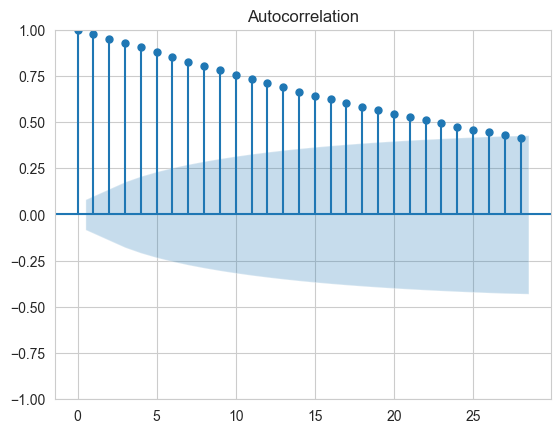

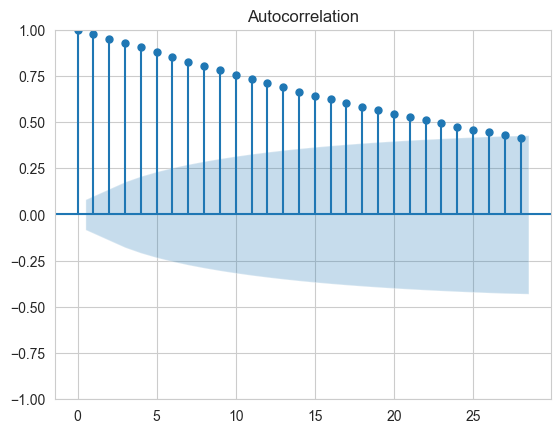

In [41]:
# [Gráfico] ACF de serie temporal
plot_acf(semanas['total_casos'])

De acuerdo a los resultado de la prueba Mann-Kendall para evaluar tendencias monotónicas, la serie de casos por semana epidemiológica no sigue una tendencia, con valores de estadísticos significativos (p<0.001), indicando una tendencia descendente significativa, con una correlación negativa débil. 

Las rupturas estructurales de la serie, se presentan en abril del 2016 con una caída, octubre del 2018 donde empieza el alza de casos, marzo del 2019 y febrero del 2020 con una caída abrupta de reportes, julio del 2021 donde se evidencia otra alza, diciembre del 2022 y agosto del 2023. 

La autocorrelación ACF, indica que hay autocorrelación significativa en varios rezagos, que no se puede asumir independencia temporal.


### Variables espaciales

In [42]:
# [Test] Índice de Moran

#Unir con la geometría
dpto = gdf.merge(casos, on="departamento")

# Crear matriz de pesos contiguos
w = Queen.from_dataframe(dpto, use_index=False)
w.transform = "r"  #

y = dpto['total_casos'].values
moran = Moran(y, w)

print("Índice de Moran:", moran.I)
print("Valor-p:", moran.p_sim)


('WARNING: ', 27, ' is an island (no neighbors)')
Índice de Moran: -0.000628614673085886
Valor-p: 0.34


c:\Users\Hp\anaconda3\envs\dengue\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 27.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 27, ' is an island (no neighbors)')


c:\Users\Hp\anaconda3\envs\dengue\Lib\site-packages\esda\moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


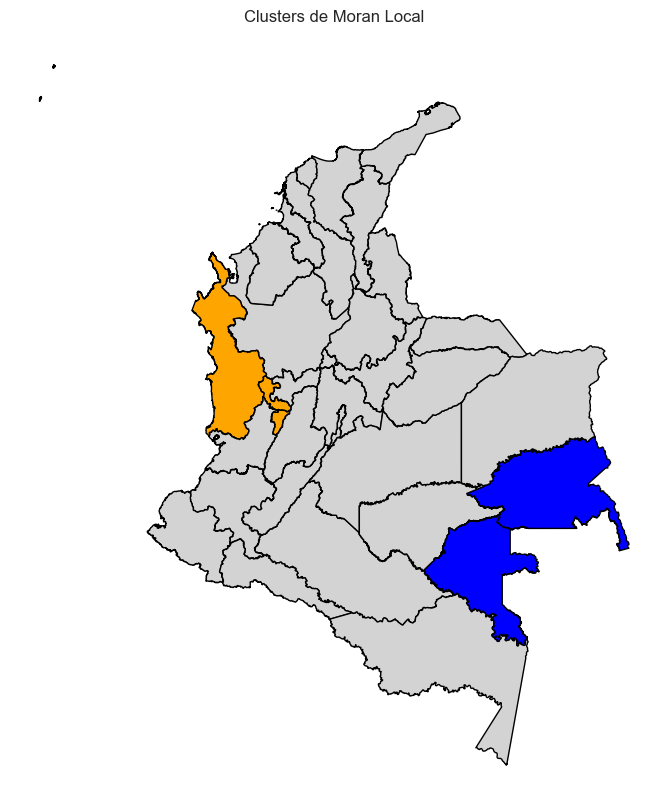

In [43]:
# Contiguos

# Crear matriz de pesos (Queen contiguidad)
w = libpysal.weights.Queen.from_dataframe(dpto, use_index=False)
w.transform = "r"
moran_loc = Moran_Local(y, w)

# Signo de Moran local: High-High, Low-Low, Low-High, High-Low
dpto['HH'] = (moran_loc.q==1) & (moran_loc.p_sim < 0.05)  # High-High
dpto['LL'] = (moran_loc.q==3) & (moran_loc.p_sim < 0.05)  # Low-Low
dpto['HL'] = (moran_loc.q==2) & (moran_loc.p_sim < 0.05)  # High-Low
dpto['LH'] = (moran_loc.q==4) & (moran_loc.p_sim < 0.05)  # Low-High

# Crear una columna con el tipo de cluster
def cluster_label(row):
    if row['HH']: return 'High-High'
    elif row['LL']: return 'Low-Low'
    elif row['HL']: return 'High-Low'
    elif row['LH']: return 'Low-High'
    else: return 'No Signif'

dpto['cluster'] = dpto.apply(cluster_label, axis=1)

# Definir colores
colors = {
    'High-High':'red',
    'Low-Low':'blue',
    'High-Low':'orange',
    'Low-High':'lightgreen',
    'No Signif':'lightgrey'
}

# Graficar mapa
fig, ax = plt.subplots(1, 1, figsize=(10,10))
dpto.plot(color=dpto['cluster'].map(colors), edgecolor='black', ax=ax)
plt.title("Clusters de Moran Local")
plt.axis('off')
plt.show()

El índice de moran indica autocorrelación positiva moderada, es decir, que en los municipios con muchos casos tienden a estar cercanos entre sí, pero no es fuerte. Con el valor-p (0.009) se puede afirmar de que los casos se agregan especialmente en algunos municipios; es decir, los municipios con más casos tienden a estar cerca unos de otros. En el mapa se identifica el cluster de mayor foco de casos en los municipios de Soledad, Malambo y Galapa. El coldspots se identifica en el municipio de Santa Lucía.


De acuerdo al índice de moran, no existe una autocorrelación espacial de casos, no se representa un patrón espacial claro. 

Los departamentos de Chocó, Cauca, Risaralda y Quindío, representan un bloque alto bajo de relación según el indice. Mientras que, Guainía y Vaupés son los coldspots de Colombia en casos de dengue.
